# Exploration et traitement des variables

## Introduction (résumé)

Ce notebook présente les étapes de travail et les choix techniques, avec une progression section par section jusqu'aux résultats exploitables pour la suite du projet.

Le sommaire ci-dessous permet d'accéder directement aux sections principales.

## Sommaire cliquable

- [1. Imports](#sec-1-imports)
- [2. Chargement-des-données](#sec-2-chargement-des-donnees)
- [3. Premier regard](#sec-3-premier-regard)
- [4. Distributions des variables cibles](#sec-4-distributions-des-variables-cibles)
- [5. Valeurs manquantes](#sec-5-valeurs-manquantes)
- [6. Variables catégorielles](#sec-6-variables-categorielles)
- [7. Analyse croisée — Variables catégorielles vs sinistralité](#sec-7-analyse-croisee-variables-categorielles-vs-sinistralite)
- [8. Étude univariée — Variables numériques](#sec-8-etude-univariee-variables-numeriques)
- [9. Corrélations](#sec-9-correlations)
- [10. Détection du plafond à 500 000€](#sec-10-detection-du-plafond-a-500-000)
- [11. Vérifications complémentaires](#sec-11-verifications-complementaires)
- [12. Synthèse et prochaines étapes](#sec-12-synthese-et-prochaines-etapes)

<a id="sec-1-imports"></a>

## 1.Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from scipy.stats import fisher_exact
from sklearn.feature_selection import mutual_info_classif

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

import warnings
warnings.filterwarnings('ignore')

<a id="sec-2-chargement-des-donnees"></a>

## 2.Chargement-des-données

On dispose de trois fichiers :
- **train_input** : les caractéristiques des contrats (374 variables)
- **train_output** : les variables cibles (FREQ, CM, CHARGE)
- **test_input** : les contrats à prédire

On fusionne train_input et train_output sur `ID` et `ANNEE_ASSURANCE` pour avoir un dataset de travail complet.

In [26]:
train_input = pd.read_csv("data/train_input.csv")
train_output = pd.read_csv("data/train_output.csv")
test_input = pd.read_csv("data/test_input.csv")

train = train_input.merge(train_output, on=["ID", "ANNEE_ASSURANCE"], how="inner")

print(f"train_input  : {train_input.shape}")
print(f"train_output : {train_output.shape}")
print(f"test_input   : {test_input.shape}")
print(f"train (mergé): {train.shape}")
print(f"\nColonnes cibles : {train_output.columns.tolist()}")

train_input  : (383610, 374)
train_output : (383610, 5)
test_input   : (95852, 374)
train (mergé): (383610, 377)

Colonnes cibles : ['ID', 'FREQ', 'CM', 'ANNEE_ASSURANCE', 'CHARGE']


<a id="sec-3-premier-regard"></a>

## 3. Premier regard

### 3.1. Dimensions et types

In [27]:
print(f"Train : {train.shape[0]:,} lignes × {train.shape[1]} colonnes")
print(f"Test  : {test_input.shape[0]:,} lignes × {test_input.shape[1]} colonnes")

print(f"\nTypes de variables (train_input) :")
print(train_input.dtypes.value_counts())

Train : 383,610 lignes × 377 colonnes
Test  : 95,852 lignes × 374 colonnes

Types de variables (train_input) :
object     280
int64       58
float64     36
Name: count, dtype: int64


280 variables catégorielles contre 94 numériques. Le dataset est majoritairement composé de variables texte. C'est un point important pour la suite : il faudra comprendre lesquelles sont de vraies catégorielles et lesquelles sont des numériques déguisées (tranches, codes ordonnés, etc.).

### 3.2. Premières lignes

In [28]:
display(train.head())

,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1,DUREE_REQANEUF,CARACT4,CARACT5,TYPBAT1,INDEM2,TYPBAT2,FRCH1,FRCH2,DEROG1,DEROG2,DEROG3,DEROG4,DEROG5,DEROG6,DEROG7,...,NBJRR1_MMAX_A,NBJRR1_MSOM_A,NBJRR5_MM_A,NBJRR5_MMAX_A,NBJRR5_MSOM_A,NBJRR10_MM_A,NBJRR10_MMAX_A,NBJRR10_MSOM_A,NBJRR30_MM_A,NBJRR30_MMAX_A,NBJRR30_MSOM_A,NBJRR100_MM_A,NBJRR100_MMAX_A,NBJRR100_MSOM_A,RR_VOR_MM_A,RR_VOR_MMAX_A,RRAB_VOR_MM_A,RRAB_VOR_MMAX_A,ANNEE_ASSURANCE,ESPINSEE,AN_EXERC,ZONE,FREQ,CM,CHARGE
0,1,ACT1,VOC6,1,0,N,N,NaN,NaN,N,NaN,absence de surface,0,NaN,CLASS5,0,2,NaN,N,N,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,NaN,ANNEE5,3,0.0000,0.0000,0.0000
1,2,ACT1,VOC6,1,0,N,N,NaN,NaN,N,NaN,absence de surface,0,NaN,CLASS6,0,1,NaN,N,N,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,NaN,ANNEE5,3,0.0000,0.0000,0.0000
2,3,ACT1,VOC6,1,2,N,R,NaN,NaN,N,NaN,absence de surface,0,NaN,CLASS6,0,1,NaN,N,N,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4027,NaN,ANNEE5,3,0.0000,0.0000,0.0000
3,4,ACT1,VOC6,2,0,N,N,NaN,NaN,N,NaN,absence de surface,0,NaN,CLASS8,0,1,NaN,N,O,N,N,N,N,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2466,NaN,ANNEE5,3,0.0000,0.0000,0.0000
4,5,ACT1,VOC6,2,1,N,N,NaN,NaN,N,NaN,absence de surface,0,NaN,CLASS9,0,1,NaN,N,N,N,N,N,N,N,...,03. <= 19,03. <= 132,04. >= 6,04. >= 12,04. >= 71,04. >= 4,04. >= 8,04. >= 45,04. >= 1,03. <= 3,04. >= 11,01. <= 0,01. <= 0,01. <= 0,03. <= 102,03. <= 232,04. >= 25,02. <= 57,0.8384,NaN,ANNEE5,3,0.0000,0.0000,0.0000


###3.3. Statistiques descriptives des variables cibles

In [29]:
display(train_output.describe())

print(f"\nFREQ :")
print(f"  % == 0 : {(train['FREQ'] == 0).mean()*100:.2f}%")
print(f"  % > 0  : {(train['FREQ'] > 0).mean()*100:.2f}%")
print(f"  Moyenne : {train['FREQ'].mean():.6f}")

print(f"\nCM :")
print(f"  Nb NaN        : {train['CM'].isna().sum()}")
print(f"  Moyenne (hors NaN) : {train['CM'].dropna().mean():.2f}")
print(f"  Médiane (hors NaN) : {train['CM'].dropna().median():.2f}")

print(f"\nCHARGE :")
print(f"  % == 0  : {(train['CHARGE'] == 0).mean()*100:.2f}%")
print(f"  Moyenne : {train['CHARGE'].mean():.2f}")

,ID,FREQ,CM,ANNEE_ASSURANCE,CHARGE
count,383610.0000,383610.0000,383610.0000,383610.0000,383610.0000
mean,191805.5000,0.0125,182.5216,0.7016,186.0871
std,110738.8127,0.3571,6699.9674,0.3524,6800.4903
min,1.0000,0.0000,-5751.0000,0.0027,-5751.0000
25%,95903.2500,0.0000,0.0000,0.3890,0.0000
50%,191805.5000,0.0000,0.0000,0.8822,0.0000
75%,287707.7500,0.0000,0.0000,1.0000,0.0000
max,383610.0000,182.5000,500000.0000,2.0000,552000.0000



FREQ :
  % == 0 : 99.25%
  % > 0  : 0.75%
  Moyenne : 0.012452

CM :
  Nb NaN        : 0
  Moyenne (hors NaN) : 182.52
  Médiane (hors NaN) : 0.00

CHARGE :
  % == 0  : 99.39%
  Moyenne : 186.09


Quelques points à retenir :
- **FREQ** : moyenne à 0.0125, ce qui signifie qu'en moyenne un contrat exposé 1 an génère ~0.012 sinistre. Le max à 182.5 correspond à un contrat très peu exposé ayant subi un sinistre (ex : 1 sinistre sur 2 jours → FREQ = 1/0.0055 ≈ 182).
- **CM** : moyenne à 182€ tirée vers le bas par les 99.25% de contrats sans sinistre (CM = 0). La médiane à 0 confirme cette structure. Chez les sinistrés, le CM moyen monte à ~24k€ avec un écart-type de 73k€ très dispersé.
- **ANNEE_ASSURANCE** : l'exposition moyenne est de 0.70 an. Le max à 2 ans indique que certains contrats couvrent plusieurs exercices. C'est cette variable qui servira d'offset dans le modèle de fréquence.
- **CHARGE** : FREQ × CM. Même structure que CM, dominée par les zéros, avec des valeurs extrêmes jusqu'à 552k€.

<a id="sec-4-distributions-des-variables-cibles"></a>

## 4. Distributions des variables cibles

Avant de toucher aux features, on regarde ce qu'on cherche à prédire. L'objectif est de comprendre la structure des cibles : est-ce que FREQ est rare ? CM est-il asymétrique ? Y a-t-il des valeurs extrêmes ?

### 4.1. Histogrammes

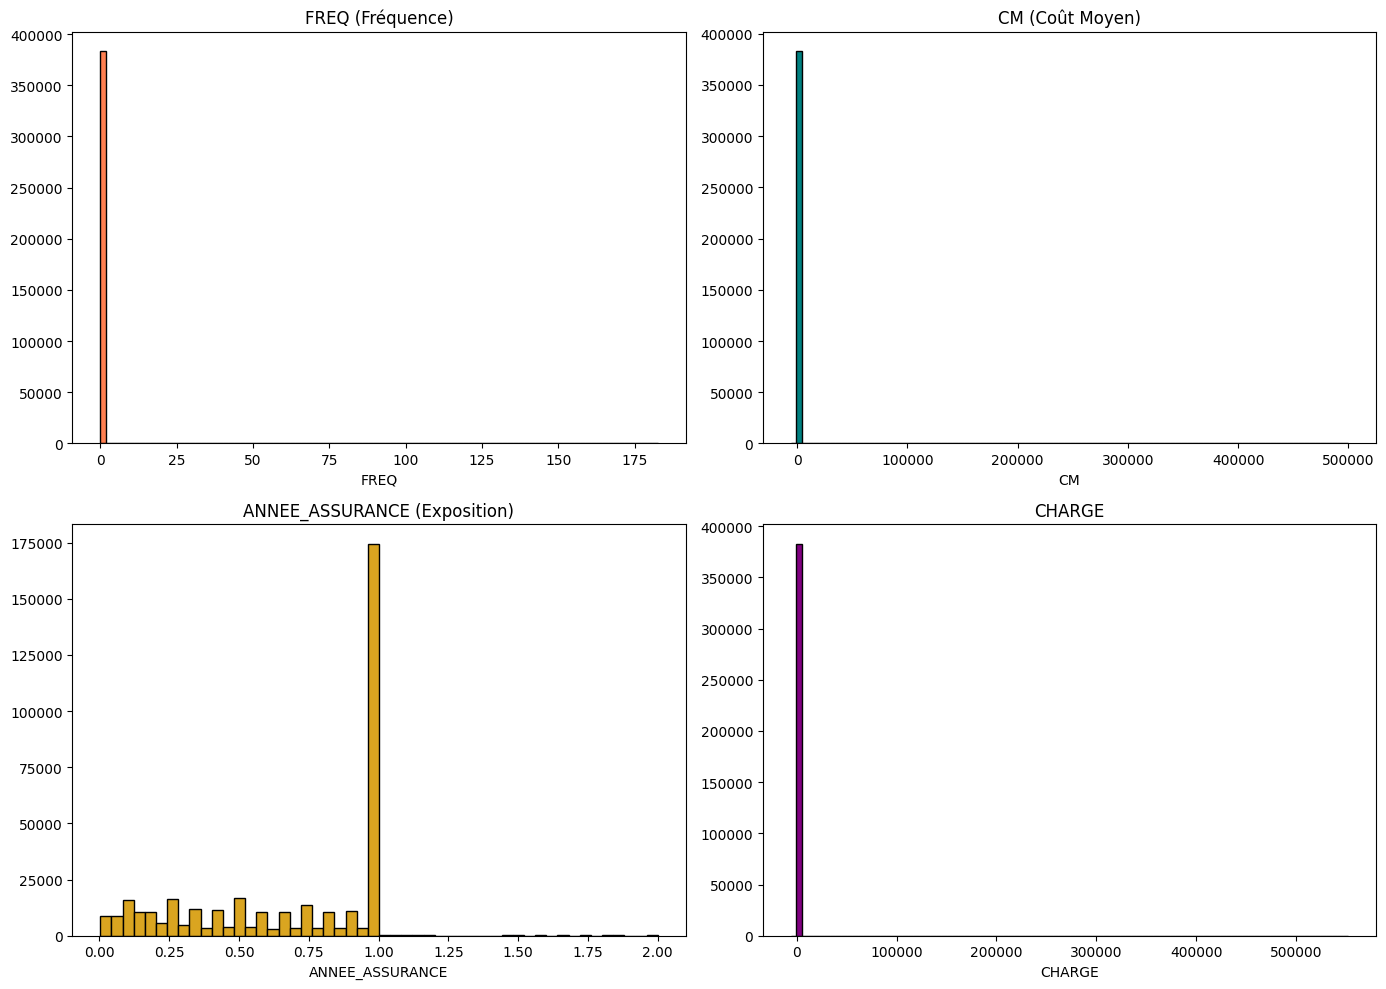

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(train['FREQ'], bins=100, color='coral', edgecolor='black')
axes[0, 0].set_title('FREQ (Fréquence)')
axes[0, 0].set_xlabel('FREQ')

axes[0, 1].hist(train['CM'].dropna(), bins=100, color='teal', edgecolor='black')
axes[0, 1].set_title('CM (Coût Moyen)')
axes[0, 1].set_xlabel('CM')

axes[1, 0].hist(train['ANNEE_ASSURANCE'], bins=50, color='goldenrod', edgecolor='black')
axes[1, 0].set_title('ANNEE_ASSURANCE (Exposition)')
axes[1, 0].set_xlabel('ANNEE_ASSURANCE')

axes[1, 1].hist(train['CHARGE'], bins=100, color='purple', edgecolor='black')
axes[1, 1].set_title('CHARGE')
axes[1, 1].set_xlabel('CHARGE')

plt.tight_layout()
plt.show()

Plusieurs constats :
- **FREQ** : 99.25% de zéros. La sinistralité est un événement très rare. On est dans un cadre classique de données zero-inflated.
- **CM** : écrasé vers 0 avec une queue très longue jusqu'à 500 000€. Le plafond à 500k est visible, on y reviendra.
- **ANNEE_ASSURANCE** : la majorité des contrats ont une exposition de 1 an, mais beaucoup ont des expositions partielles (résiliations, mises en force en cours d'année).
- **CHARGE** : même profil que CM, dominé par les zéros.

Ces distributions écrasées ne sont pas exploitables visuellement en l'état. On zoome sur les sinistrés uniquement.

### 4.2. Zoom sur les sinistrés uniquement

Nb sinistrés : 2,894 (0.75%)

FREQ (quand > 0) :


count   2894.0000
mean       1.6505
std        3.7692
min        0.9682
25%        1.0000
50%        1.0014
75%        1.5532
max      182.5000
Name: FREQ, dtype: float64


CM (quand sinistre) :


count     2894.0000
mean     24193.8919
std      73288.3577
min      -5751.0000
25%        192.7275
50%        902.9850
75%       6000.0000
max     500000.0000
Name: CM, dtype: float64

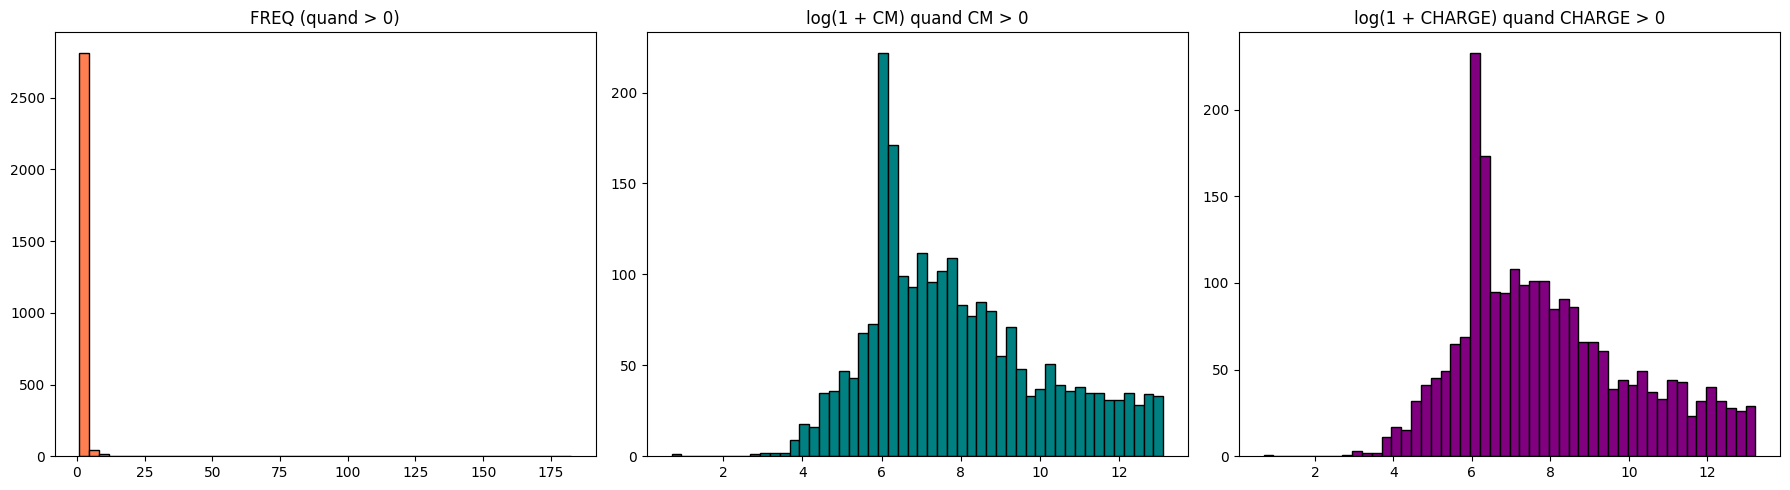

In [31]:
sinistres = train[train['FREQ'] > 0]

print(f"Nb sinistrés : {len(sinistres):,} ({len(sinistres)/len(train)*100:.2f}%)")
print(f"\nFREQ (quand > 0) :")
display(sinistres['FREQ'].describe())
print(f"\nCM (quand sinistre) :")
display(sinistres['CM'].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sinistres['FREQ'], bins=50, color='coral', edgecolor='black')
axes[0].set_title('FREQ (quand > 0)')

axes[1].hist(np.log1p(sinistres[sinistres['CM'] > 0]['CM']), bins=50, color='teal', edgecolor='black')
axes[1].set_title('log(1 + CM) quand CM > 0')

axes[2].hist(np.log1p(sinistres[sinistres['CHARGE'] > 0]['CHARGE']), bins=50, color='purple', edgecolor='black')
axes[2].set_title('log(1 + CHARGE) quand CHARGE > 0')

plt.tight_layout()
plt.show()

En isolant les 2 894 contrats sinistrés (0.75% du portefeuille) :
- **FREQ** : c'est un ratio nb_sinistres / exposition. Un contrat exposé 1 mois avec 1 sinistre donne FREQ = 12. Ça explique les valeurs élevées (max = 182.5) ce ne sont pas forcément des multi-sinistrés, mais des contrats à très courte exposition. La médiane ≈ 1 confirme que la plupart des sinistrés ont ~1 sinistre sur ~1 an.
- **log(CM)** : la distribution en log révèle une forme bimodale. Un premier mode autour de 5-6 (CM ~ 150-400€, petits sinistres) et un étalement vers 12-13 (CM > 100k€, sinistres graves). Signal fort pour séparer attritionnels et graves dans la modélisation.
- **CM négatif** : le minimum à -5 751€ indique des recours ou des régularisations. À traiter.
- **Plafond à 500 000€** : le max de CM est exactement 500k, ce qui confirme un écrêtement. Les sinistres au-delà sont censurés.

<a id="sec-5-valeurs-manquantes"></a>

## 5. Valeurs manquantes

Les NA peuvent représenter plusieurs problèmes différents: "information non collectée", "non applicable au type de contrat", ou encore "donnée manquante dans un référentiel externe" (météo, socio-démo...). Il faut donc les traiter en fonction.

### 5.1. Vue d'ensemble

In [32]:
missing = train_input.isnull().sum()
missing_pct = (missing / len(train_input) * 100).round(2)
missing_df = pd.DataFrame({
    'Nb_manquants': missing,
    'Pct_manquants': missing_pct
}).sort_values('Pct_manquants', ascending=False)

missing_with = missing_df[missing_df['Nb_manquants'] > 0]

print(f"Variables avec au moins 1 NA : {len(missing_with)} / {train_input.shape[1]}")
print(f"Variables sans aucun NA      : {train_input.shape[1] - len(missing_with)}")
print(f"\nTop 30 :")
display(missing_with.head(30))

Variables avec au moins 1 NA : 278 / 374
Variables sans aucun NA      : 96

Top 30 :


,Nb_manquants,Pct_manquants
DEROG14,383602,100.0000
DEROG13,382317,99.6600
DEROG16,380358,99.1500
CARACT2,368284,96.0000
CARACT3,368284,96.0000
TYPBAT1,353336,92.1100
DEROG12,349078,91.0000
BDTOPO_BAT_MAX_HAUTEUR,237385,61.8800
HAUTEUR_MAX,237385,61.8800
BDTOPO_BAT_MAX_HAUTEUR_MAX,237385,61.8800


278 variables sur 374 ont au moins un NA. On remarque aussi des blocs entiers de variables avec exactement le même nombre de NA (ex : 237 385 ou 217 712), ce qui correspond à des sources de données externes (météo, socio-démo, BDTOPO...) qui ne sont disponibles que pour une partie du portefeuille. Les NA arrivent par bloc, pas variable par variable.

**Un NA peut aussi être informatif**. Un contrat sans données météo rattachées n'a pas le même profil qu'un contrat avec. L'absence d'information est elle-même une information. On vérifiera plus tard si le fait d'être NA sur certains blocs est corrélé à la sinistralité.

### 5.2. Répartition par tranche

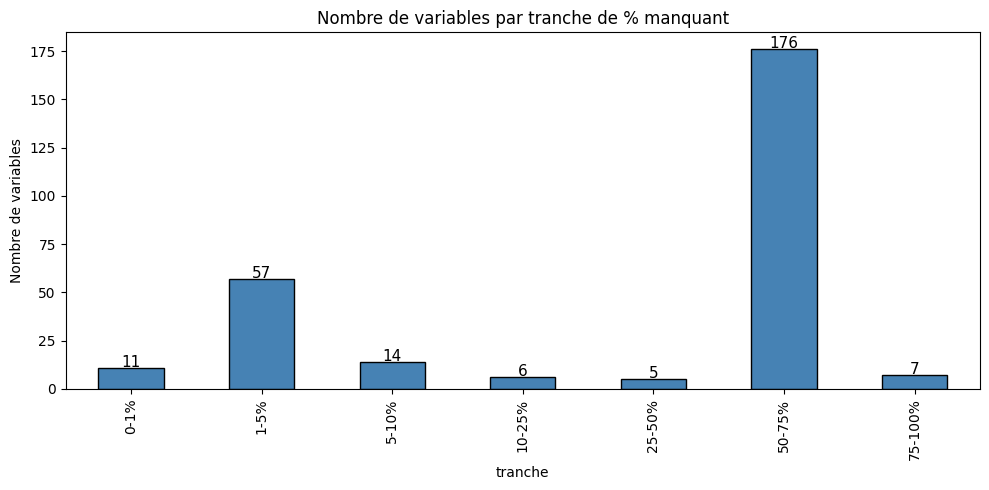

Résumé :
  0-1%       : 11 variables
  1-5%       : 57 variables
  5-10%      : 14 variables
  10-25%     : 6 variables
  25-50%     : 5 variables
  50-75%     : 176 variables
  75-100%    : 7 variables


In [33]:
fig, ax = plt.subplots(figsize=(10, 5))

bins = [0, 1, 5, 10, 25, 50, 75, 100]
labels = ['0-1%', '1-5%', '5-10%', '10-25%', '25-50%', '50-75%', '75-100%']
missing_with = missing_with.copy()
missing_with['tranche'] = pd.cut(missing_with['Pct_manquants'], bins=bins, labels=labels)

counts = missing_with['tranche'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')

for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=11)

ax.set_title("Nombre de variables par tranche de % manquant")
ax.set_ylabel("Nombre de variables")
plt.tight_layout()
plt.show()

print("Résumé :")
for label, count in counts.items():
    print(f"  {label:10s} : {count} variables")

La structure est claire :
- **176 variables entre 50-75% de NA** : c'est le bloc météo/distance. Ces variables viennent d'un référentiel externe qui ne couvre qu'une partie du portefeuille. On ne peut pas les imputer naïvement — il faudra créer un flag "données météo disponibles oui/non" et traiter le bloc à part.
- **57 variables entre 1-5%** : probablement le bloc socio-démo (INSEE). Peu de NA, imputation classique possible.
- **7 variables à 75-100%** : quasi vides, candidates à la suppression.
- **11 variables à moins de 1%** : NA résiduels, imputation simple.

La question maintenant : est-ce que les NA sont aléatoires, ou est-ce que le fait d'être NA sur un bloc est lié à la sinistralité ? Si oui, supprimer ces variables ferait perdre du signal.

### 5.3 Les NA sont-ils liés à la sinistralité ?

On compare le taux de sinistre, le CM moyen et le taux de graves entre les contrats avec NA et ceux sans NA, pour chaque variable. Si les ratios s'éloignent de 1, le NA est informatif et on devra le conserver sous forme de flag binaire.

#### 5.3.1 Test NA informatifs

In [34]:
df = train_input.merge(train_output, on=['ID', 'ANNEE_ASSURANCE'], how='inner')
df['HAS_SINISTRE'] = (df['FREQ'] > 0).astype(int)

cols_with_na = [c for c in train_input.columns 
                if train_input[c].isnull().mean() > 0.005 and c != 'ID']

results_na = []

for col in cols_with_na:
    mask_na = df[col].isnull()
    
    taux_na = df.loc[mask_na, 'HAS_SINISTRE'].mean()
    taux_ok = df.loc[~mask_na, 'HAS_SINISTRE'].mean()
    ratio_freq = taux_na / taux_ok if taux_ok > 0 else np.nan
    
    cm_na = df.loc[mask_na & (df['CM'] > 0), 'CM'].mean()
    cm_ok = df.loc[~mask_na & (df['CM'] > 0), 'CM'].mean()
    ratio_cm = cm_na / cm_ok if cm_ok > 0 else np.nan
    
    results_na.append({
        'Variable': col,
        'Pct_NA': round(df[col].isnull().mean() * 100, 1),
        'Taux_sin_NA': round(taux_na * 100, 3),
        'Taux_sin_OK': round(taux_ok * 100, 3),
        'Ratio_freq': round(ratio_freq, 2),
        'CM_moy_NA': round(cm_na, 0) if pd.notnull(cm_na) else np.nan,
        'CM_moy_OK': round(cm_ok, 0) if pd.notnull(cm_ok) else np.nan,
        'Ratio_CM': round(ratio_cm, 2) if pd.notnull(ratio_cm) else np.nan
    })

na_info = pd.DataFrame(results_na)
na_info['Score'] = na_info.apply(
    lambda r: max(abs(np.log(r['Ratio_freq'])) if pd.notnull(r['Ratio_freq']) and r['Ratio_freq'] > 0 else 0,
                  abs(np.log(r['Ratio_CM'])) if pd.notnull(r['Ratio_CM']) and r['Ratio_CM'] > 0 else 0),
    axis=1
)
na_info = na_info.sort_values('Score', ascending=False)

print(f"Variables testées : {len(na_info)}")
print(f"Variables où le NA est informatif (score > 0.3) : {(na_info['Score'] > 0.3).sum()}")
print(f"\nTop 30 :")
display(na_info.head(30))

Variables testées : 268
Variables où le NA est informatif (score > 0.3) : 266

Top 30 :


,Variable,Pct_NA,Taux_sin_NA,Taux_sin_OK,Ratio_freq,CM_moy_NA,CM_moy_OK,Ratio_CM,Score
0,CARACT1,1.2000,0.0860,0.7630,0.1100,14394.0000,29801.0000,0.4800,2.2073
8,DEROG13,99.7000,0.7530,1.1600,0.6500,29089.0000,175789.0000,0.1700,1.7720
11,KAPITAL11,31.0000,0.1900,1.0080,0.1900,35501.0000,29309.0000,1.2100,1.6607
17,SURFACE7,1.1000,0.3190,0.7590,0.4200,8055.0000,29877.0000,0.2700,1.3093
20,SURFACE10,2.0000,0.2410,0.7650,0.3100,11683.0000,29883.0000,0.3900,1.1712
12,KAPITAL21,1.4000,2.0660,0.7360,2.8100,32409.0000,29662.0000,1.0900,1.0332
35,RISK13,40.8000,0.3640,1.0240,0.3600,26943.0000,30421.0000,0.8900,1.0217
10,DEROG16,99.2000,0.7580,0.2770,2.7400,29815.0000,14183.0000,2.1000,1.0080
5,INDEM2,7.1000,0.3250,0.7870,0.4100,19484.0000,30100.0000,0.6500,0.8916
33,RISK10,36.7000,0.4580,0.9260,0.4900,31725.0000,29239.0000,1.0900,0.7133


266 variables sur 268 ont un NA informatif (score > 0.3) — autrement dit, presque partout, le fait d'avoir un NA change le profil de sinistralité du contrat.

Quelques observations :
- **CARACT1** (1.2% NA) : les contrats avec NA ont un taux de sinistre 9x plus faible (0.08% vs 0.76%). Le NA ici signifie probablement "caractéristique non applicable" — c'est un signal fort.
- **KAPITAL21** (1.4% NA) : effet inverse — les contrats avec NA ont un taux de sinistre 2.8x plus élevé. Le NA est clairement un profil de risque différent.
- **Bloc météo** (~57% NA) : toutes les variables météo ont exactement le même pattern (score = 0.62, ratio CM = 0.54). Normal — c'est le même bloc de lignes qui n'a pas de données météo. Un seul flag `FLAG_HAS_METEO` suffira pour capturer ce signal.
- **TYPBAT1** (92% NA) : quasi vide, mais le ratio CM montre que les rares contrats renseignés ont un CM moyen 1.5x plus élevé.

**Conclusion** : on ne peut pas simplement supprimer les variables à fort taux de NA. La stratégie sera :
1. Créer des **flags par bloc** (météo, socio-démo, RISK, HAUTEUR) — un seul flag par bloc puisque les NA tombent sur les mêmes lignes
2. Créer des **flags individuels** pour les variables avec un signal fort (CARACT1, KAPITAL21, KAPITAL11, etc.)
3. Supprimer les variables à **>50% de NA** après avoir créé les flags (l'info est conservée dans le flag)
4. Imputer le reste (médiane pour les numériques, mode ou "MISSING" pour les catégorielles)

#### 5.3.2 Significativité statistique des NA informatifs

Le score basé sur le log-ratio peut être trompeur quand le groupe NA est petit : un ratio de 9x calculé sur 3 sinistrés n'est pas fiable. On ajoute un test de Fisher exact pour vérifier que la différence de taux de sinistre entre NA et non-NA est statistiquement significative.

In [35]:
results_signif = []

for _, row in na_info.iterrows():
    col = row['Variable']
    mask_na = df[col].isnull()
    
    # Table de contingence 2x2
    a = df.loc[mask_na, 'HAS_SINISTRE'].sum()       # NA et sinistre
    b = mask_na.sum() - a                             # NA et pas sinistre
    c = df.loc[~mask_na, 'HAS_SINISTRE'].sum()       # non-NA et sinistre
    d = (~mask_na).sum() - c                          # non-NA et pas sinistre
    
    if min(a, b, c, d) >= 0 and (a + b) > 0 and (c + d) > 0:
        odds_ratio, p_value = fisher_exact([[a, b], [c, d]])
    else:
        odds_ratio, p_value = np.nan, np.nan
    
    results_signif.append({
        'Variable': col,
        'n_sinistres_NA': int(a),
        'n_sinistres_OK': int(c),
        'p_value_Fisher': p_value,
        'Score_original': row['Score']
    })

signif_df = pd.DataFrame(results_signif)
signif_df['Significatif_5pct'] = signif_df['p_value_Fisher'] < 0.05

print(f"Variables avec NA informatif ET significatif (p < 0.05) : "
      f"{signif_df['Significatif_5pct'].sum()} / {len(signif_df)}")
print(f"Variables avec score > 0.3 MAIS non significatif        : "
      f"{((signif_df['Score_original'] > 0.3) & (~signif_df['Significatif_5pct'])).sum()}")

# Afficher les cas problématiques : score élevé mais pas significatif
problematic = signif_df[(signif_df['Score_original'] > 0.3) & (~signif_df['Significatif_5pct'])]
if len(problematic) > 0:
    print(f"\n⚠️ Variables à score élevé mais non significatif :")
    display(problematic)
else:
    print(f"\n✅ Toutes les variables à score > 0.3 sont significatives")

display(signif_df.sort_values('p_value_Fisher').head(20))

Variables avec NA informatif ET significatif (p < 0.05) : 211 / 268
Variables avec score > 0.3 MAIS non significatif        : 55

⚠️ Variables à score élevé mais non significatif :


,Variable,n_sinistres_NA,n_sinistres_OK,p_value_Fisher,Score_original,Significatif_5pct
1,DEROG13,2879,15,0.1038,1.7720,False
183,DEROG12,2630,264,0.8195,0.5798,False
189,PROPORTION_21,152,2742,0.4648,0.4943,False
200,FFM_VOR_COM_MM_A_Y,148,2746,0.4871,0.4620,False
201,FFM_VOR_COM_MMAX_A_Y,148,2746,0.4871,0.4620,False
202,FXI3SAB_VOR_COM_MMAX_A_Y,148,2746,0.4871,0.4620,False
203,FXI3SAB_VOR_COM_MM_A_Y,148,2746,0.4871,0.4620,False
205,NB_CASERNES,148,2746,0.4868,0.4620,False
206,LOG_APA3,148,2746,0.4870,0.4620,False
207,LOG_A1_A2,148,2746,0.4870,0.4620,False


,Variable,n_sinistres_NA,n_sinistres_OK,p_value_Fisher,Score_original,Significatif_5pct
2,KAPITAL11,226,2668,0.0000,1.6607,True
6,RISK13,569,2325,0.0000,1.0217,True
9,RISK10,644,2250,0.0000,0.7133,True
121,DISTANCE_312,1286,1608,0.0000,0.6162,True
52,DISTANCE_2,1286,1608,0.0000,0.6162,True
148,DISTANCE_244,1286,1608,0.0000,0.6162,True
122,DISTANCE_313,1289,1605,0.0000,0.6162,True
126,DISTANCE_324,1288,1606,0.0000,0.6162,True
11,DISTANCE_311,1296,1598,0.0000,0.6349,True
133,RR_VOR_MMAX_A,1282,1612,0.0000,0.6162,True


211 variables sur 268 ont un NA à la fois informatif (score > 0.3) ET statistiquement significatif (Fisher p < 0.05). C'est la grande majorité — le signal est réel.

Les 55 variables à score élevé mais non significatif se décomposent en deux groupes très distincts :

- **DEROG13** (score = 1.77, p = 0.10) : seulement 15 sinistrés dans le groupe non-NA. Le ratio est spectaculaire mais l'échantillon est trop petit pour conclure. On créera le flag mais sans garantie qu'il soit utile.

- **Bloc météo/socio-démo/altitude** (48 variables, score ≈ 0.46, p ≈ 0.49) : toutes ont exactement 148 sinistrés dans le groupe NA et 2 746 dans le groupe non-NA. Ce sont les mêmes lignes — un seul bloc de contrats sans données externes. Le test de Fisher ne rejette pas parce que le taux de sinistre est quasi identique entre NA et non-NA (148 ~> 220k ≈ 2746 ~> 163k). Autrement dit, **le NA de ce bloc n'est pas informatif pour la sinistralité** contrairement à ce que le log-ratio suggérait. Un seul flag `FLAG_HAS_SOCIO` suffira, mais il ne sera probablement pas retenu par le modèle.

- **SURFACE9, DEROG12** : même problème — échantillon insuffisant ou écart non significatif.

**Conclusion** : le test de Fisher permet de filtrer les faux positifs du log-ratio. Sur les 266 variables initialement identifiées comme "NA informatif", 55 ne passent pas le test de significativité. On les conserve quand même dans le pipeline (les flags sont gratuits), mais on sait qu'elles n'apporteront probablement pas de signal.

<a id="sec-6-variables-categorielles"></a>

## 6. Variables catégorielles

On a 280 variables de type `object`. Mais dans un dataset d'assurance, beaucoup de "catégorielles" sont en réalité des tranches numériques codées en texte (`"01. moins de 500m²"`, `"03. entre 1000 et 2000"`...). Il faut distinguer :
- Les **vraies catégorielles** (activité, zone géographique, type de bâtiment...)
- Les **ordinales déguisées** (tranches de surface, de capital, de risque...)
- Les **numériques en texte** (surface, altitude, nombre de ménages...)

Cette distinction conditionne tout l'encodage.

### 6.1. Cardinalité

In [36]:
cat_cols = train_input.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'ID']

cardinality = train_input[cat_cols].nunique().sort_values(ascending=False)

print(f"Nombre de variables catégorielles : {len(cat_cols)}")

print(f"\nRépartition de la cardinalité :")
print(f"  1 modalité (constantes)  : {(cardinality <= 1).sum()}")
print(f"  2 modalités (binaires)   : {(cardinality == 2).sum()}")
print(f"  3-5 modalités            : {((cardinality > 2) & (cardinality <= 5)).sum()}")
print(f"  6-10 modalités           : {((cardinality > 5) & (cardinality <= 10)).sum()}")
print(f"  11-20 modalités          : {((cardinality > 10) & (cardinality <= 20)).sum()}")
print(f"  >20 modalités            : {(cardinality > 20).sum()}")

print(f"\nTop 20 par cardinalité :")
display(cardinality.head(20))

Nombre de variables catégorielles : 280

Répartition de la cardinalité :
  1 modalité (constantes)  : 4
  2 modalités (binaires)   : 29
  3-5 modalités            : 209
  6-10 modalités           : 35
  11-20 modalités          : 3
  >20 modalités            : 0

Top 20 par cardinalité :


SURFACE4         16
SURFACE6         16
INDEM2           12
TAILLE2          10
PROPORTION_11    10
LOG_APA3         10
LOG_AVA1         10
MEN_MAIS         10
MEN_COLL         10
TAILLE1          10
PROPORTION_31    10
PROPORTION_24    10
PROPORTION_23    10
PROPORTION_22    10
PROPORTION_21    10
ACTIVIT2          9
PROPORTION_33     9
LOG_A2_A3         9
PROPORTION_32     9
AN_EXERC          9
dtype: int64

Aucune variable à plus de 20 modalités — le dataset est déjà pré-discrétisé. La grande majorité (209 variables) ont entre 3 et 5 modalités, ce qui est typique de variables découpées en tranches.

Les 4 constantes (1 seule modalité) sont inutiles — à supprimer. Les 29 binaires sont probablement des O/N qu'on convertira en 0/1.

Regardons maintenant à quoi ressemblent concrètement ces modalités pour distinguer les vraies catégorielles des ordinales déguisées.

### 6.2. Identifier ordinales vs vraies catégorielles

In [37]:
cat_cols_no_id = [c for c in train_input.select_dtypes(include='object').columns if c != 'ID']

ordinal_vars = []
binary_vars = []
true_cat_vars = []

for col in cat_cols_no_id:
    vals = train_input[col].dropna().unique()
    n = len(vals)
    
    if n <= 1:
        continue
    
    # Binaires N/O
    if set(vals) <= {'N', 'O'}:
        binary_vars.append(col)
        continue
    
    # Ordinales : modalités qui commencent par un chiffre suivi d'un point (01., 02., ...)
    non_missing = [v for v in vals if str(v) != 'MISSING']
    all_ordinal = all('.' in str(v)[:4] and str(v)[0].isdigit() for v in non_missing) if non_missing else False
    
    if all_ordinal:
        ordinal_vars.append(col)
    else:
        true_cat_vars.append(col)

print(f"Binaires (N/O)           : {len(binary_vars)}")
print(f"Ordinales (tranches)     : {len(ordinal_vars)}")
print(f"Vraies catégorielles     : {len(true_cat_vars)}")

print(f"\n--- Exemples d'ordinales ---")
for col in ordinal_vars[:5]:
    print(f"\n  {col} ({train_input[col].nunique()} mod.) :")
    print(f"    {sorted(train_input[col].dropna().unique())[:5]}")

print(f"\n--- Vraies catégorielles ---")
for col in true_cat_vars:
    print(f"  {col:25s} ({train_input[col].nunique()} mod.) → {train_input[col].dropna().unique()[:5]}")

Binaires (N/O)           : 24
Ordinales (tranches)     : 225
Vraies catégorielles     : 27

--- Exemples d'ordinales ---

  DISTANCE_111 (4 mod.) :
    ['01. <= 13', '02. <= 25', '03. <= 961', '04. >= 961']

  DISTANCE_112 (4 mod.) :
    ['01. <= 1', '02. <= 4', '03. <= 937', '04. >= 937']

  DISTANCE_121 (4 mod.) :
    ['01. <= 6', '02. <= 13', '03. <= 952', '04. >= 952']

  DISTANCE_122 (4 mod.) :
    ['01. <= 13', '02. <= 28', '03. <= 959', '04. >= 959']

  DISTANCE_123 (4 mod.) :
    ['01. <= 48', '02. <= 92', '03. <= 145', '04. >= 145']

--- Vraies catégorielles ---
  ACTIVIT2                  (9 mod.) → ['ACT1' 'ACT2' 'ACT5' 'ACT8' 'ACT9']
  VOCATION                  (8 mod.) → ['VOC6' 'VOC7' 'VOC1' 'VOC4' 'VOC8']
  CARACT1                   (3 mod.) → ['N' 'R' 'O']
  CARACT3                   (3 mod.) → ['R' 'O' 'N']
  CARACT4                   (6 mod.) → ['absence de surface' 'Surface de moins d' 'Surface entre 501'
 'Surface entre 1001' 'Surface entre 1501']
  TYPBAT1         

La détection automatique donne une image claire :
- **225 ordinales** : des tranches numériques encodées en texte (`"01. <= 13"`, `"02. <= 25"`...). On extraira le numéro d'ordre (1, 2, 3, 4) pour les convertir en numériques.
- **24 binaires** (N/O) : conversion directe en 0/1.
- **27 vraies catégorielles** : à traiter au cas par cas.

Parmi les 27 "vraies catégorielles", on repère encore des faux amis :
- **SURFACE4, SURFACE6** : les modalités sont `'500'`, `'1000'`, `'1500'`... ce sont des numériques en texte, pas des catégories.
- **TAILLE1, TAILLE2** : des tranches ordonnées (`"01 - [0-250k]"`, `"02 - [250k-500k]"`...) — on peut extraire le numéro d'ordre.
- **COEFASS** : tranches (`"0"`, `"01-10"`, `"11-20"`...) — ordinal.
- **AN_EXERC** : `"ANNEE1"` à `"ANNEE9"` — ordinal.
- **FRCH1** : mix de types (int et string `'1'`) — à nettoyer en numérique.
- **CARACT1, RISK6, RISK9-13, EQUIPEMENT2** : 3 modalités N/R/O — pas du binaire classique, mais un ordinal (Non / Réduit / Oui).
- **TYPBAT1** : `'volaille'`, `'lapin'`, `'porcs'`... — une vraie catégorielle métier (type d'élevage).

On traitera tout ça dans le notebook de data engineering. Pour l'instant, on passe à l'analyse croisée avec les cibles.

<a id="sec-7-analyse-croisee-variables-categorielles-vs-sinistralite"></a>

## 7. Analyse croisée — Variables catégorielles vs sinistralité


On croise les principales variables catégorielles avec le taux de sinistre pour identifier celles qui discriminent le plus. L'idée : si une modalité a un taux de sinistre 3x supérieur à la moyenne, c'est une variable qui pèsera dans le modèle.


### 7.1. Taux de sinistre par variable

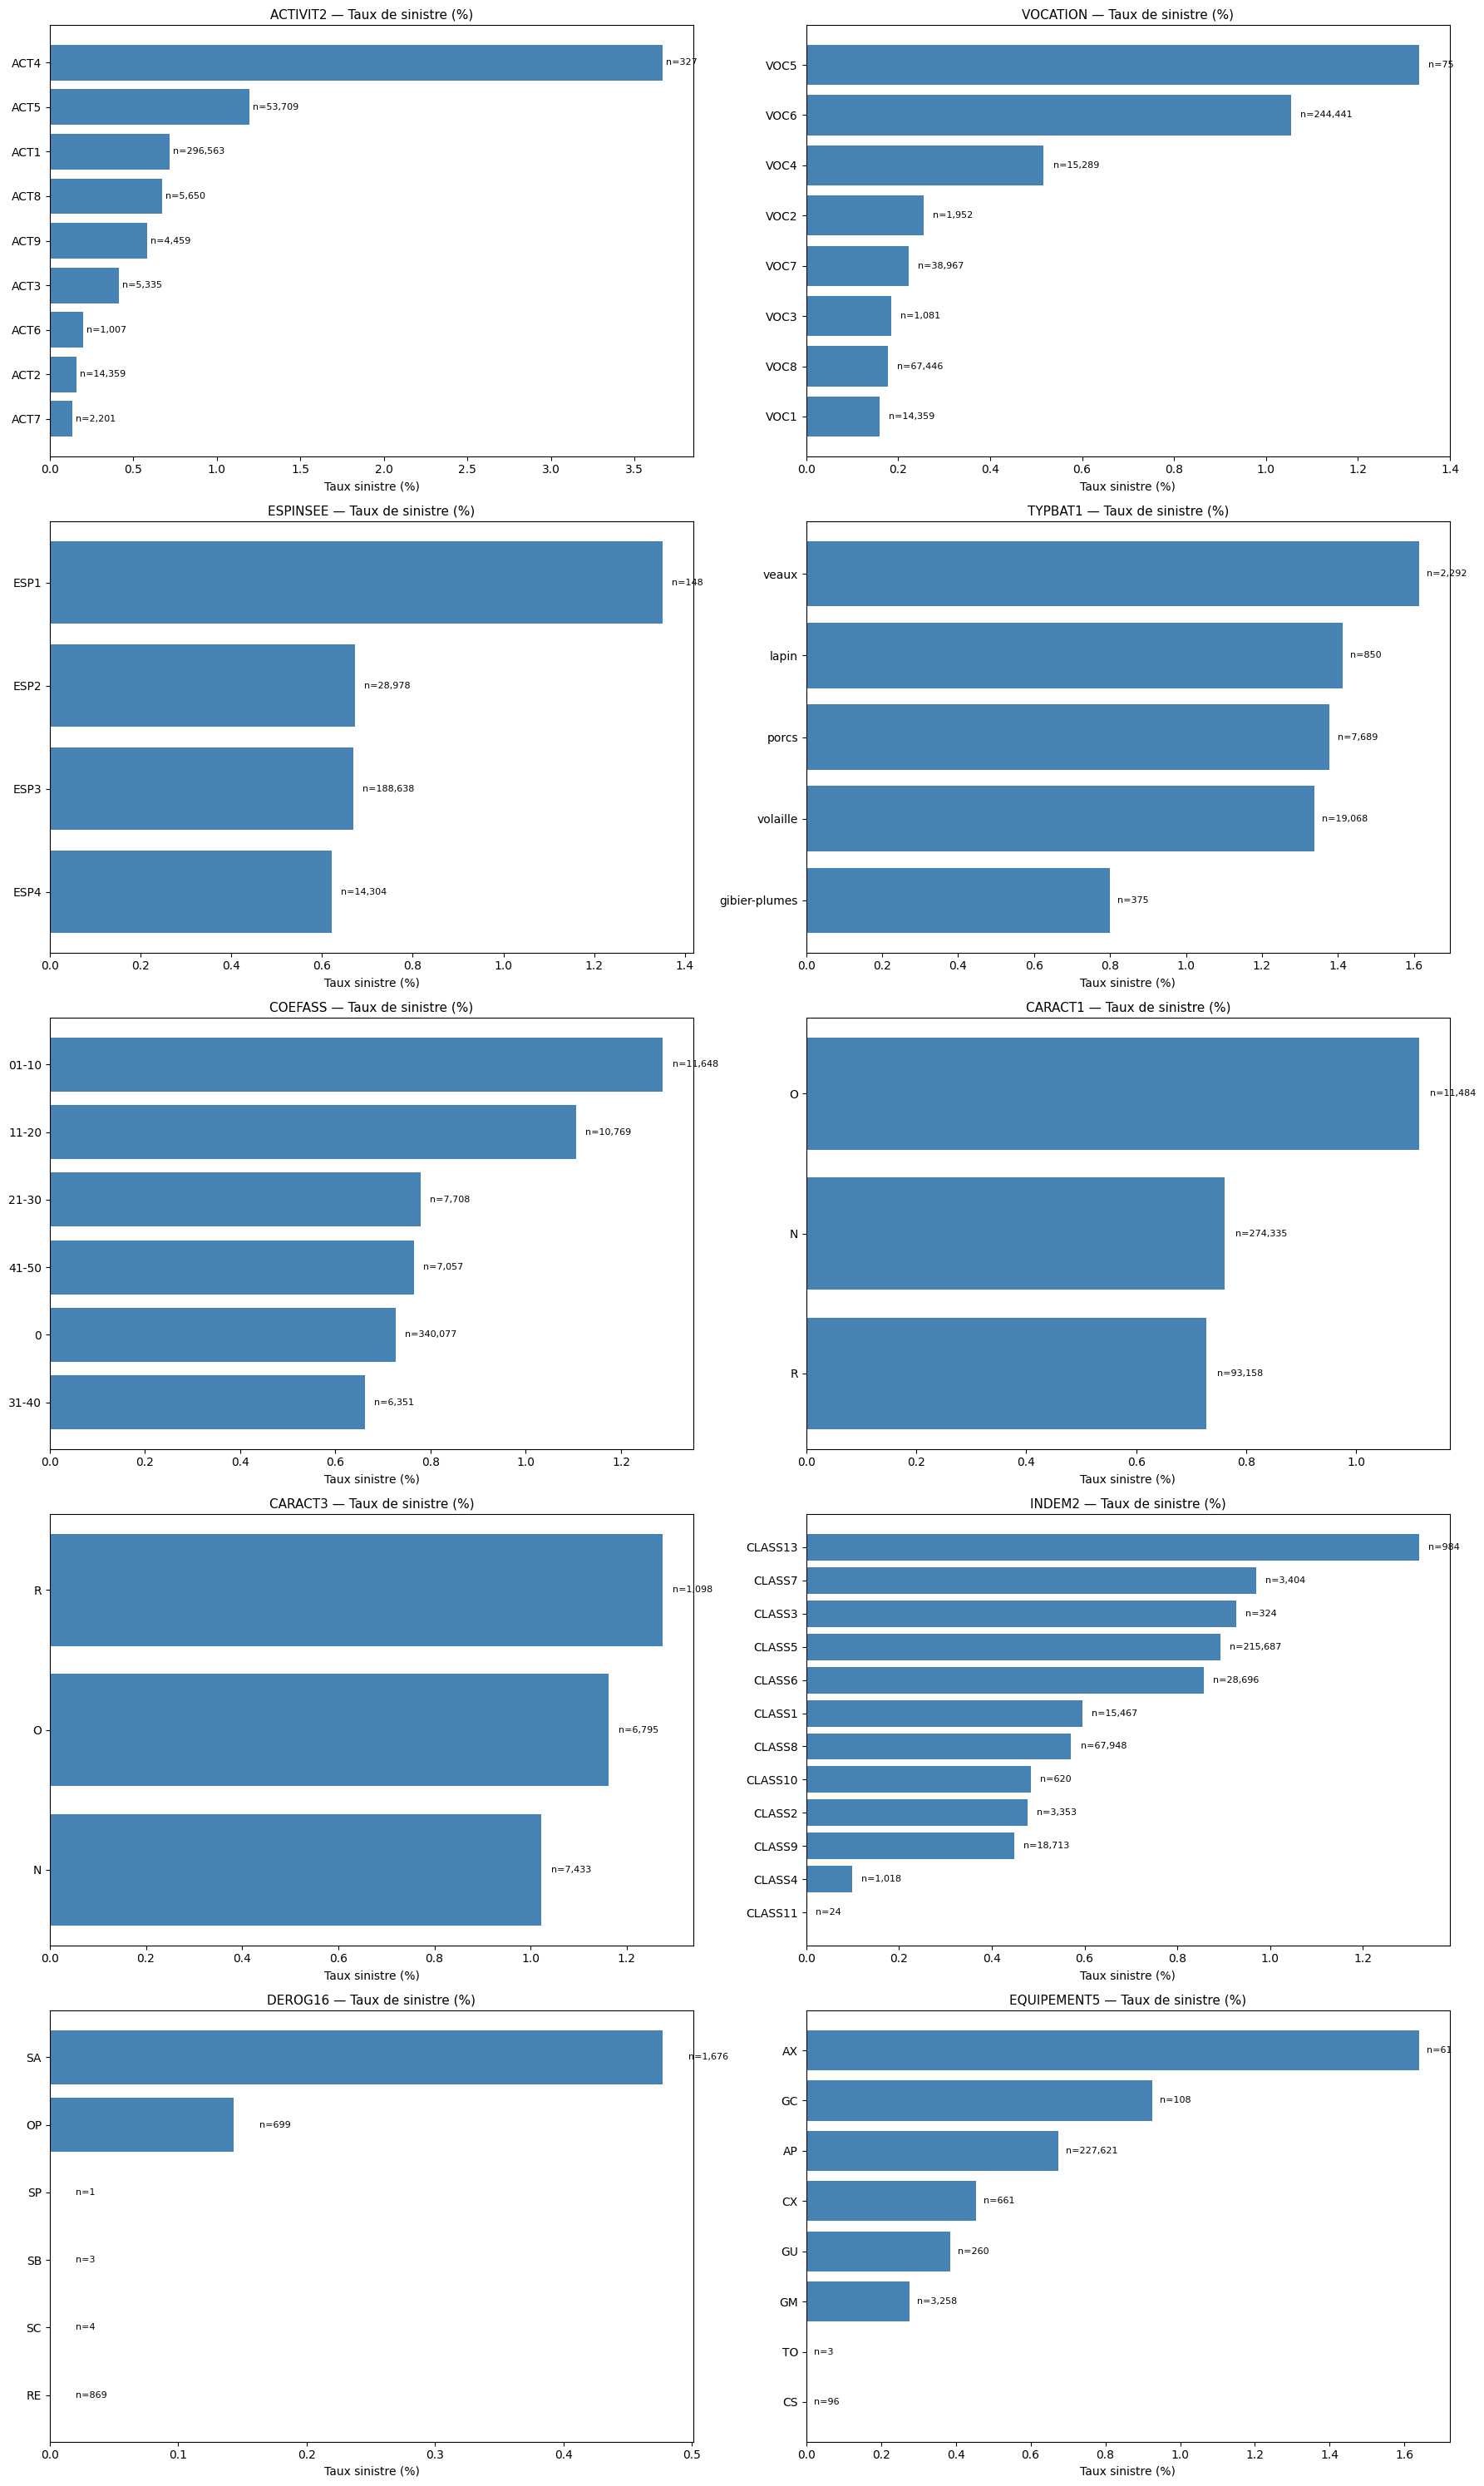

In [38]:
df = train_input.merge(train_output, on=['ID', 'ANNEE_ASSURANCE'], how='inner')
df['HAS_SINISTRE'] = (df['FREQ'] > 0).astype(int)

key_vars = ['ACTIVIT2', 'VOCATION', 'ESPINSEE', 'TYPBAT1', 'COEFASS',
            'CARACT1', 'CARACT3', 'INDEM2', 'DEROG16', 'EQUIPEMENT5']

fig, axes = plt.subplots(5, 2, figsize=(18, 30))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    if var not in df.columns:
        continue
    
    grouped = df.groupby(var).agg(
        nb_contrats=('HAS_SINISTRE', 'count'),
        taux_sinistre=('HAS_SINISTRE', 'mean'),
        charge_moyenne=('CHARGE', 'mean')
    ).sort_values('taux_sinistre', ascending=True)
    
    top = grouped.nlargest(15, 'nb_contrats').sort_values('taux_sinistre', ascending=True)
    
    ax = axes[i]
    bars = ax.barh(top.index.astype(str), top['taux_sinistre'] * 100, color='steelblue')
    ax.set_title(f'{var} — Taux de sinistre (%)', fontsize=11)
    ax.set_xlabel('Taux sinistre (%)')
    
    for bar, n in zip(bars, top['nb_contrats']):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'n={n:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

Les graphiques révèlent des variables très discriminantes :

- **ACTIVIT2** : ACT4 (3.5% de sinistres) est 35x plus risqué que ACT7 (0.1%). Mais ACT4 ne compte que 327 contrats — à surveiller en termes de crédibilité statistique. ACT5 et ACT1 (gros volumes) sont autour de 0.8-1.5%.
- **VOCATION** : VOC5 explose à ~1.3% mais sur seulement 75 contrats. VOC6 (244k contrats, 0.9%) et VOC4 (15k, ~0.8%) sont les plus fiables.
- **TYPBAT1** : variable métier intéressante — les élevages de veaux (1.6%) et lapins (1.3%) sont plus sinistrés que la volaille (1.0%) ou le gibier-plumes (0.6%). Mais attention, 92% de NA sur cette variable.
- **ESPINSEE** : ESP1 se démarque nettement (environ 1.3%) vs ESP3/ESP4 (environ 0.5-0.7%). Effet zone géographique probable.
- **COEFASS** : les tranches hautes (01-10, 11-20) sont plus sinistrées que le coefficient 0. Logique — un coefficient d'assurance plus élevé reflète un historique de sinistres.
- **CARACT1** : O (1.1%) > N (0.7%) > R (0.15%). La modalité "R" est nettement moins risquée.
- **INDEM2** : CLASS13 (1.2%) et CLASS7 (1.0%) en tête. CLASS11 et CLASS4 quasi nuls mais très peu de contrats.
- **DEROG16** : SA domine (~0.5%) mais seulement 3k contrats renseignés sur 383k (99.2% de NA).
- **EQUIPEMENT5** : AX (1.5%) très au-dessus, mais 61 contrats seulement. AP (227k contrats, ~0.8%) est la référence fiable.

De manière générale, les variables à faible volume (n < 500) donnent des taux extrêmes mais peu fiables. On gardera ça en tête pour la modélisation.

<a id="sec-8-etude-univariee-variables-numeriques"></a>

## 8. Étude univariée — Variables numériques

On passe aux variables numériques. L'objectif est de comprendre leurs distributions, repérer les outliers, et identifier celles qui ont le plus de variance exploitable.


### 8.1. Stats descriptives des numériques

In [39]:
num_cols = train_input.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'ID']

print(f"Nombre de variables numériques : {len(num_cols)}")

desc = train_input[num_cols].describe().T
desc['skew'] = train_input[num_cols].skew()
desc['kurtosis'] = train_input[num_cols].kurtosis()
desc['pct_zeros'] = (train_input[num_cols] == 0).mean() * 100

desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis', 'pct_zeros']]
desc = desc.sort_values('std', ascending=False)

print(f"\nTop 30 par écart-type :")
display(desc.head(30))

Nombre de variables numériques : 93

Top 30 par écart-type :


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,pct_zeros
KAPITAL11,264605.0000,98060.7793,137843.7317,0.0000,0.0000,40000.0000,125000.0000,500000.0000,1.5780,1.6084,29.0271
KAPITAL12,383610.0000,120546.0885,124946.6604,0.0000,0.0000,125000.0000,175000.0000,500000.0000,1.1391,1.0930,31.0224
KAPITAL10,383610.0000,67639.9794,123142.2535,0.0000,0.0000,0.0000,87500.0000,500000.0000,2.1262,3.8468,60.0495
KAPITAL32,383610.0000,74441.6790,94312.9429,0.0000,0.0000,22500.0000,125000.0000,300000.0000,1.1617,0.0704,34.8573
KAPITAL33,383607.0000,7080.8014,40506.0831,0.0000,0.0000,0.0000,0.0000,300000.0000,6.2926,39.6476,95.4357
KAPITAL27,383610.0000,5699.6689,14205.2347,0.0000,0.0000,0.0000,0.0000,50000.0000,2.3759,4.2437,84.5439
KAPITAL26,383610.0000,2470.3214,13967.1538,0.0000,0.0000,0.0000,0.0000,100000.0000,6.1553,38.1981,96.2955
CA3,383610.0000,1228.0311,6995.8794,0.0000,0.0000,0.0000,0.0000,50000.0000,6.0140,35.9630,96.0228
KAPITAL28,383610.0000,931.6754,5426.7216,0.0000,0.0000,0.0000,0.0000,50000.0000,6.4205,44.6397,96.8353
KAPITAL25,383610.0000,3379.8754,4973.5789,0.0000,1000.0000,1000.0000,3000.0000,20000.0000,2.3008,4.3949,6.8859


Les variables numériques ont un profil typique de données d'assurance :
- **Très asymétriques** : skewness souvent > 5, kurtosis > 30. Les distributions sont écrasées à gauche avec des queues longues à droite.
- **Beaucoup de zéros** : la plupart des variables de capital (KAPITAL) et de surface ont 80-98% de zéros. Normal — la majorité des contrats n'ont pas de valeur renseignée pour chaque poste.
- **Ordres de grandeur très différents** : de 0-10 000 pour les surfaces à 0-500 000 pour les capitaux. Une normalisation sera nécessaire pour certains modèles.
- **Variables quasi-constantes** : celles avec >98% de zéros et un kurtosis > 100 apportent très peu de variance. Candidates à la suppression ou à la transformation en flag binaire (0 vs >0).

On va maintenant regarder les distributions des variables les plus dispersées pour repérer les outliers.

### 8.2. Distributions des principales numériques

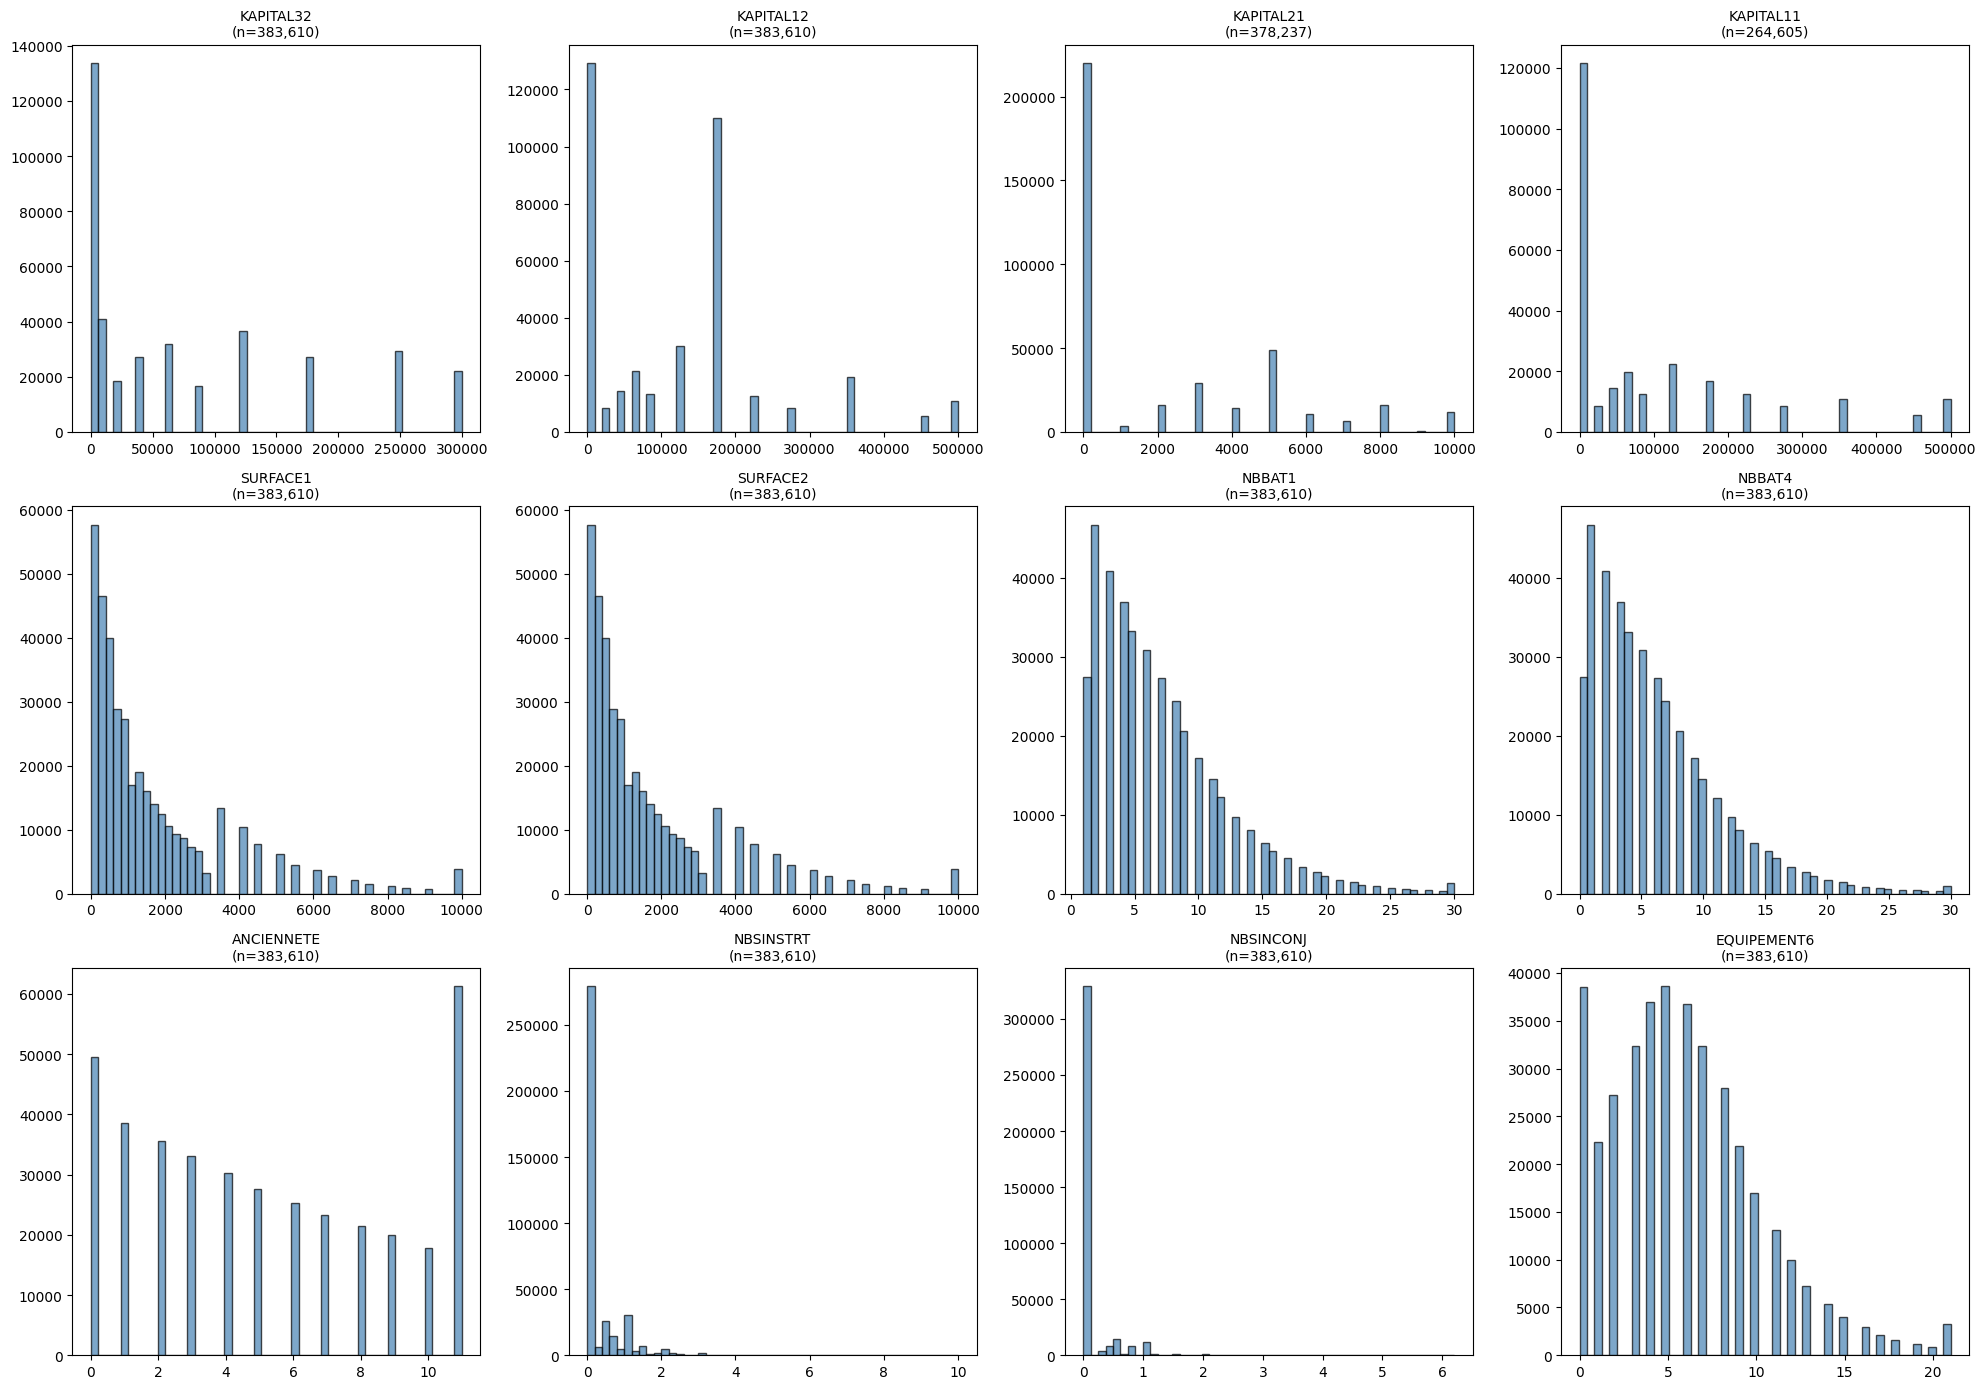

In [40]:
top_num = ['KAPITAL32', 'KAPITAL12', 'KAPITAL21', 'KAPITAL11',
           'SURFACE1', 'SURFACE2', 'NBBAT1', 'NBBAT4',
           'ANCIENNETE', 'NBSINSTRT', 'NBSINCONJ', 'EQUIPEMENT6']

# Garder seulement celles qui existent
top_num = [c for c in top_num if c in train_input.columns]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(top_num):
    data = train_input[col].dropna()
    
    # En log pour les très asymétriques
    data_pos = data[data > 0]
    if len(data_pos) > 100 and data_pos.max() / (data_pos.median() + 1) > 10:
        axes[i].hist(np.log1p(data_pos), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'log(1+{col})\n(n={len(data_pos):,}, {(data==0).mean()*100:.0f}% zéros)', fontsize=10)
    else:
        axes[i].hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col}\n(n={len(data):,})', fontsize=10)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Quelques observations par variable :

**Capitaux (KAPITAL)** :
- **KAPITAL32** et **KAPITAL12** : distributions étalées entre 0 et 300-500k€, avec un pic à 0 (contrats sans ce poste de capital). Pas de valeur aberrante évidente, mais des distributions très asymétriques.
- **KAPITAL21** : écrasé vers 0 avec 95% de zéros. Quand il est renseigné, il monte jusqu'à 10k€. Variable très sparse.
- **KAPITAL11** : 31% de NA (264k obs sur 383k). Distribution bimodale avec un pic à 0 et un autre autour de 125-175k€.

**Surfaces** :
- **SURFACE1** et **SURFACE2** : distributions similaires, étalées de 0 à 10 000 m² avec un pic marqué en dessous de 1 000 m². Queue longue mais pas d'outlier extrême.

**Bâtiments (NBBAT)** :
- **NBBAT1** : nombre de bâtiments par contrat, de 0 à 30. Distribution décroissante avec un mode à 1-3 bâtiments. Quelques exploitations à 25-30 bâtiments.
- **NBBAT4** : même profil, légèrement décalé.

**Sinistralité passée** :
- **NBSINSTRT** : 65% de zéros, puis décroissance rapide. Les contrats avec >3 sinistres passés sont rares.
- **NBSINCONJ** : encore plus concentré — 80% à 0, quelques contrats à 5-7 sinistres conjoints.

**ANCIENNETE** : distribution quasi-uniforme de 0 à 10 ans avec un pic à 10+ (contrats fidèles). Pas d'outlier.

**EQUIPEMENT6** : distribution en cloche centrée autour de 5-10, avec une queue à droite jusqu'à 20. Variable discrète.

<a id="sec-9-correlations"></a>

## 9. Corrélations


On regarde maintenant les liens linéaires entre variables numériques et cibles. L'objectif est double :
1. Identifier les variables les plus corrélées à la sinistralité (signal pour le modèle)
2. Repérer les groupes de variables très corrélées entre elles (redondance à traiter)

### 9.1. Corrélation avec les cibles

In [41]:
df = train_input.merge(train_output, on=['ID', 'ANNEE_ASSURANCE'], how='inner')
df['HAS_SINISTRE'] = (df['FREQ'] > 0).astype(int)

num_cols = [c for c in train_input.select_dtypes(include=['int64', 'float64']).columns if c != 'ID']
targets = ['HAS_SINISTRE', 'FREQ', 'CHARGE']

corr_with_targets = df[num_cols + targets].corr()[targets].drop(targets, errors='ignore')
corr_with_targets = corr_with_targets.reindex(
    corr_with_targets['HAS_SINISTRE'].abs().sort_values(ascending=False).index
)

print("Top 30 corrélations avec les cibles :")
display(corr_with_targets.head(30))

Top 30 corrélations avec les cibles :


,HAS_SINISTRE,FREQ,CHARGE
KAPITAL32,0.0611,0.0266,0.0272
SURFACE7,0.0592,0.0229,0.0134
SURFACE10,0.0572,0.0223,0.0211
SURFACE2,0.0572,0.0276,0.0322
SURFACE1,0.0572,0.0276,0.0322
SURFACE11,0.0560,0.0223,0.0320
SURFACE3,0.0552,0.0248,0.0310
KAPITAL12,0.0522,0.0253,0.0213
NBBAT4,0.0508,0.0254,0.0202
NBBAT1,0.0508,0.0254,0.0203


Les corrélations linéaires avec les cibles sont faibles (max ~6%). C'est attendu : avec 99.25% de zéros sur FREQ, la corrélation de Pearson est mécaniquement écrasée. Ça ne veut pas dire que les variables sont inutiles — un modèle non-linéaire (type gradient boosting) captera des interactions que Pearson ne voit pas.

Malgré ça, on distingue un groupe de tête autour de 5-6% de corrélation avec HAS_SINISTRE. Visualisons les top 20 et la matrice de corrélation entre elles.

### 9.2. Barplot des top 20 par cible

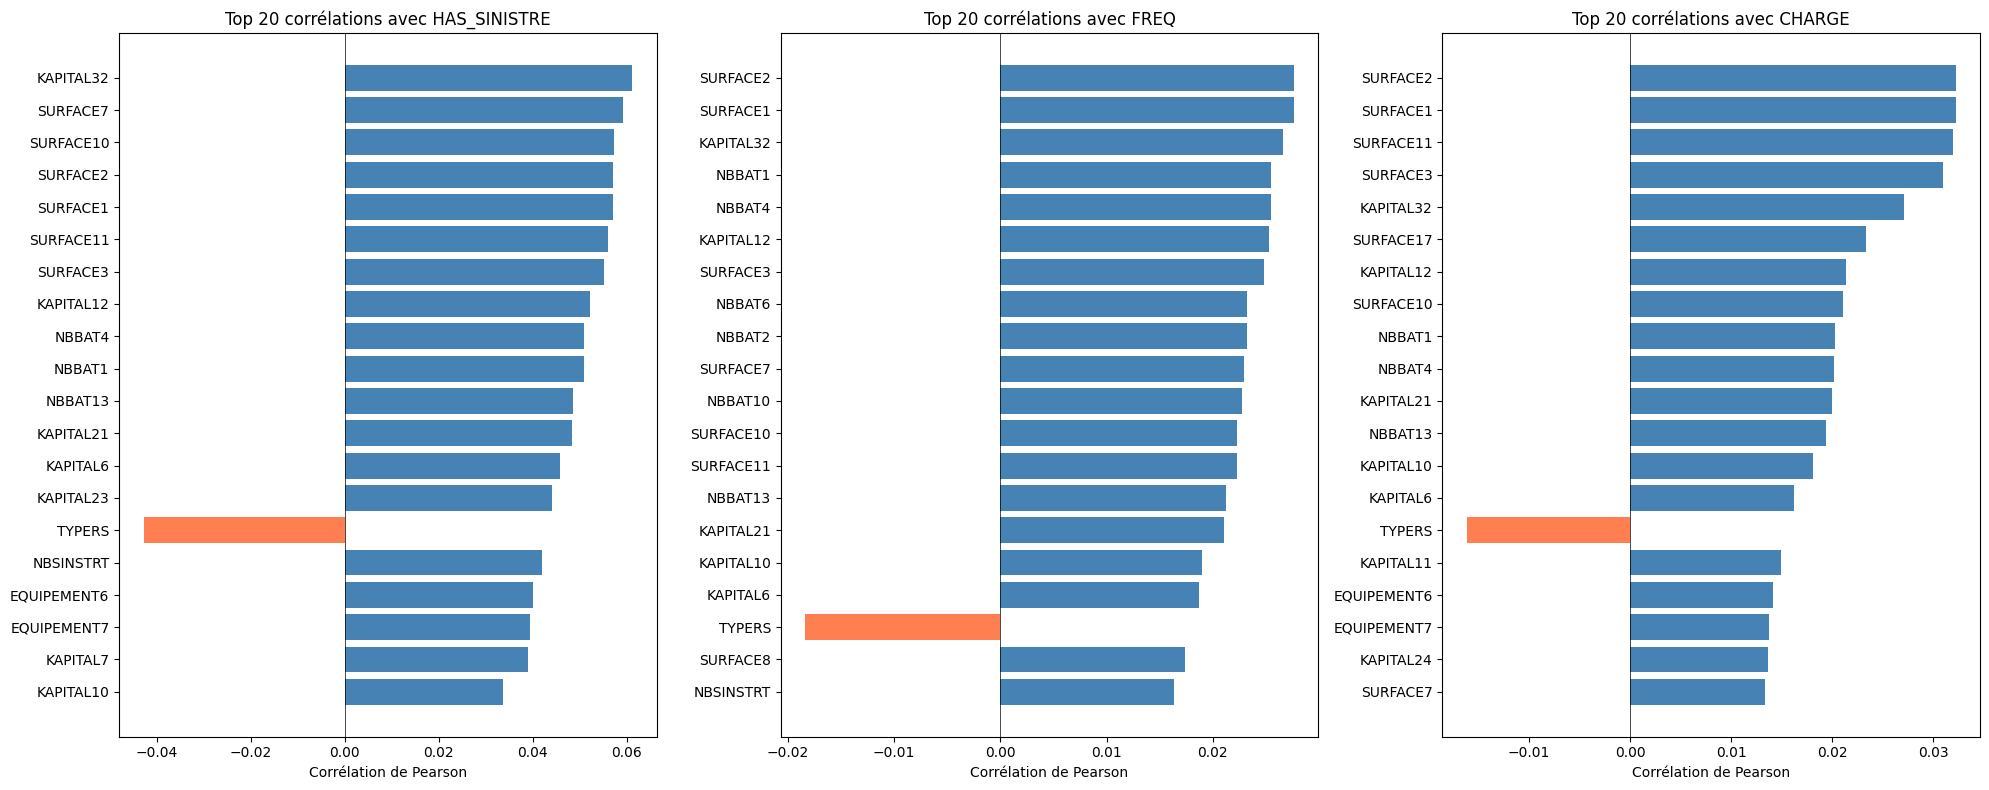

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for i, target in enumerate(targets):
    top20 = corr_with_targets[target].abs().nlargest(20)
    vals = corr_with_targets.loc[top20.index, target]
    colors = ['steelblue' if v > 0 else 'coral' for v in vals]
    
    axes[i].barh(vals.index[::-1], vals.values[::-1], color=colors[::-1])
    axes[i].set_title(f'Top 20 corrélations avec {target}', fontsize=12)
    axes[i].set_xlabel('Corrélation de Pearson')
    axes[i].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

Les mêmes familles de variables reviennent systématiquement dans les top 20 des trois cibles :
- **KAPITAL** (32, 12, 6, 21, 23...) : plus le capital assuré est élevé, plus le risque de sinistre augmente. Logique — un bâtiment de grande valeur a plus de surface exposée.
- **SURFACE** (1, 2, 3, 7, 10, 11...) : même logique, la surface est un proxy de la taille de l'exploitation.
- **NBBAT** (1, 4, 13...) : plus il y a de bâtiments, plus la probabilité qu'au moins un soit touché augmente.
- **TYPERS** : seule variable à corrélation **négative**. Certains types de personnes morales/physiques sont moins exposés.
- **NBSINSTRT** : la sinistralité passée est prédictive de la sinistralité future — classique en actuariat.
- **EQUIPEMENT** (6, 7) : le niveau d'équipement du bâtiment joue aussi.

On retrouve un schéma cohérent : **taille de l'exploitation** (capital × surface × nb bâtiments) = principal driver de la sinistralité. La matrice de corrélation va confirmer que ces variables sont fortement corrélées entre elles.

### 9.3. Matrice de corrélation entre top 30 variables

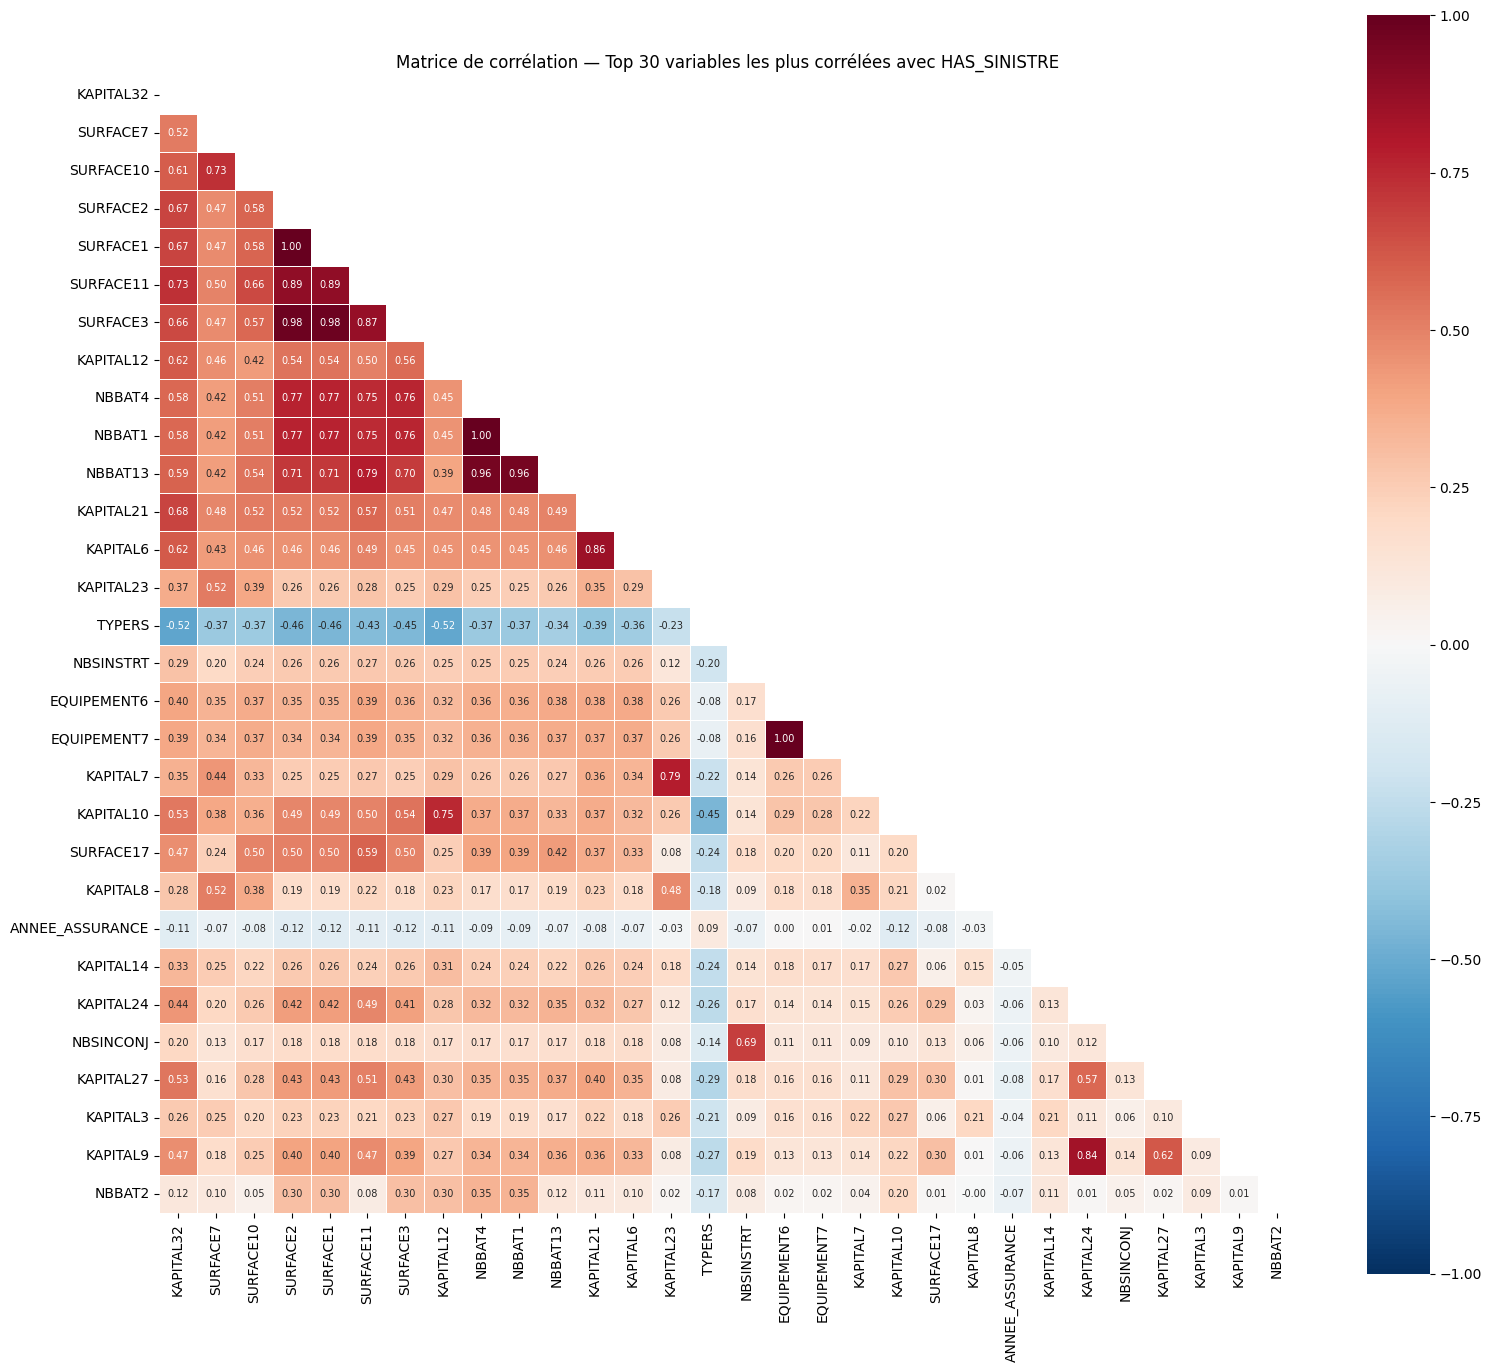

In [43]:
top30_vars = corr_with_targets['HAS_SINISTRE'].abs().nlargest(30).index.tolist()

fig, ax = plt.subplots(figsize=(16, 14))
corr_matrix = df[top30_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 7}, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation — Top 30 variables les plus corrélées avec HAS_SINISTRE', fontsize=12)
plt.tight_layout()
plt.show()

La matrice confirme ce qu'on soupçonnait — il y a des **blocs de redondance massive** :

**Corrélations quasi-parfaites (>0.95)** :
- SURFACE1 ↔ SURFACE2 : **1.00** — ce sont probablement la même variable sous deux noms. L'une des deux est à supprimer.
- NBBAT1 ↔ NBBAT4 : **1.00** — idem.
- EQUIPEMENT6 ↔ EQUIPEMENT7 : **1.00** — idem.
- SURFACE1 ↔ SURFACE11 : **0.89**, SURFACE3 ↔ SURFACE11 : **0.98** — même famille, forte redondance.
- NBBAT1 ↔ NBBAT13 : **0.96** — quasi-doublon.
- KAPITAL21 ↔ KAPITAL6 : **0.86** — corrélés mais pas identiques, on peut garder les deux.

**Blocs corrélés (0.50-0.80)** :
- Toutes les SURFACE entre elles (0.47-1.00)
- Tous les KAPITAL entre eux (0.25-0.75)
- KAPITAL ↔ SURFACE (0.40-0.67) — logique, plus c'est grand, plus c'est cher à assurer

**Variable à part** :
- **TYPERS** : corrélation **négative** avec tout le bloc taille (-0.37 à -0.52). Ce type de personne est associé à des exploitations plus petites.
- **NBSINSTRT / NBSINCONJ** : faiblement corrélés au reste (0.10-0.29). La sinistralité passée apporte une information indépendante de la taille — c'est bon signe.
- **ANNEE_ASSURANCE** : quasi-décorrélée de tout (-0.12 à 0.01). L'exposition est indépendante des caractéristiques du risque.

**Conclusion pour le data engineering** : il faudra supprimer les doublons parfaits (SURFACE1/SURFACE2, NBBAT1/NBBAT4, EQUIPEMENT6/EQUIPEMENT7) et potentiellement agréger les familles KAPITAL et SURFACE en quelques variables synthétiques pour réduire la multicolinéarité.

### 9.4. Mutual Information — dépendances non-linéaires

La corrélation de Pearson ne capte que les relations linéaires. Avec 99.25% de zéros, elle est mécaniquement écrasée. La Mutual Information (MI) mesure toute forme de dépendance statistique — y compris non-linéaire — et n'est pas affectée par le déséquilibre de la même manière.

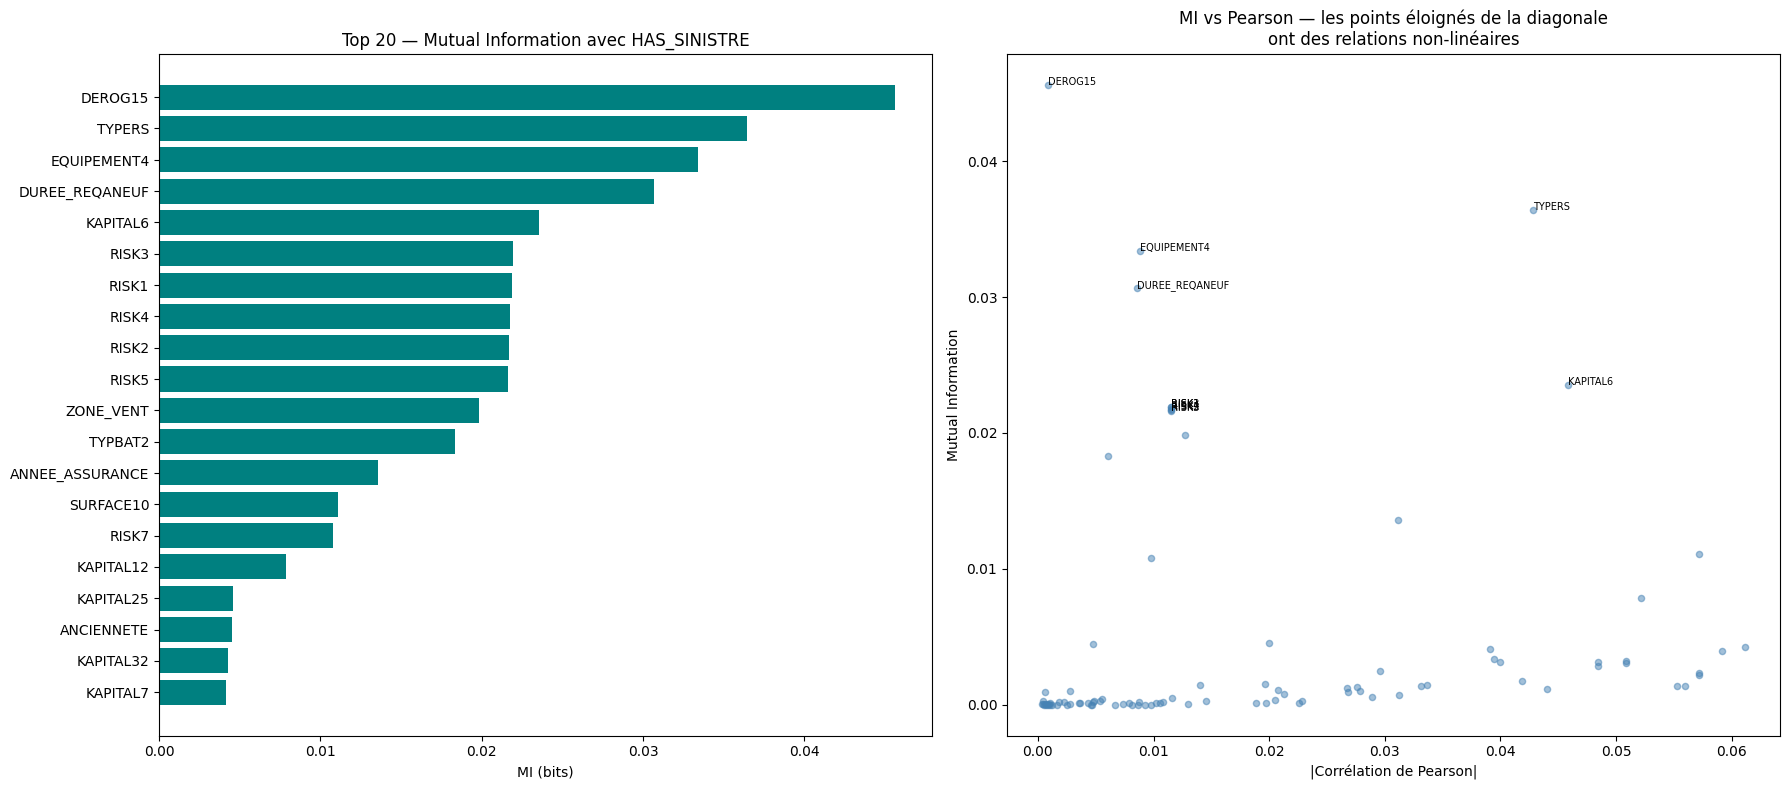

Top 20 par MI :


,Variable,MI,Pearson_abs
6,DEROG15,0.0456,0.0008
0,TYPERS,0.0364,0.0428
87,EQUIPEMENT4,0.0334,0.0088
3,DUREE_REQANEUF,0.0306,0.0086
15,KAPITAL6,0.0235,0.0459
81,RISK3,0.0219,0.0115
79,RISK1,0.0219,0.0115
82,RISK4,0.0218,0.0115
80,RISK2,0.0217,0.0115
83,RISK5,0.0216,0.0115


In [44]:
num_cols_mi = [c for c in num_cols if c in df.columns]
X_mi = df[num_cols_mi].fillna(0)
y_mi = df['HAS_SINISTRE']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({
    'Variable': num_cols_mi,
    'MI': mi_scores,
    'Pearson_abs': corr_with_targets.loc[num_cols_mi, 'HAS_SINISTRE'].abs().values
}).sort_values('MI', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 20 MI
top20_mi = mi_df.head(20)
axes[0].barh(top20_mi['Variable'][::-1], top20_mi['MI'][::-1], color='teal')
axes[0].set_title('Top 20 — Mutual Information avec HAS_SINISTRE')
axes[0].set_xlabel('MI (bits)')

# MI vs Pearson
axes[1].scatter(mi_df['Pearson_abs'], mi_df['MI'], alpha=0.5, s=20, color='steelblue')
axes[1].set_xlabel('|Corrélation de Pearson|')
axes[1].set_ylabel('Mutual Information')
axes[1].set_title('MI vs Pearson — les points éloignés de la diagonale\nont des relations non-linéaires')

# Annoter les outliers (MI élevée mais Pearson faible)
for _, row in mi_df.head(10).iterrows():
    axes[1].annotate(row['Variable'], (row['Pearson_abs'], row['MI']), fontsize=7)

plt.tight_layout()
plt.show()

print("Top 20 par MI :")
display(mi_df.head(20))

La Mutual Information révèle un ranking très différent de Pearson — et c'est l'information la plus intéressante de cette section.

**Nouvelles variables en tête (invisibles avec Pearson) :**
- **DEROG15** (MI = 0.039, Pearson = 0.001) : la variable la plus informative selon la MI, mais quasi-invisible en corrélation linéaire. C'est une variable binaire ou quasi-binaire — la relation avec la sinistralité est non-linéaire (effet de seuil). À surveiller de près dans la modélisation.
- **EQUIPEMENT4** (MI = 0.037, Pearson = 0.009) : même profil. Le niveau d'équipement a un effet non-linéaire sur le risque — probablement un seuil au-delà duquel l'équipement protège significativement.
- **DUREE_REQANEUF** (MI = 0.034, Pearson = 0.009) : la durée depuis la remise à neuf. Relation non-linéaire — un bâtiment récemment rénové n'a pas le même risque qu'un bâtiment ancien, mais la relation n'est pas proportionnelle.
- **ZONE_VENT** (MI = 0.019, Pearson = 0.013) : l'exposition au vent a un effet de seuil, pas linéaire.
- **TYPBAT2** (MI = 0.016, Pearson = 0.006) : le type de bâtiment secondaire discrimine mieux en MI qu'en Pearson.

**Variables qui changent de rang :**
- **TYPERS** : Pearson = 0.043 (4ᵉ en Pearson) mais MI = 0.029 (4ᵉ aussi). Ici les deux méthodes convergent — la relation est à la fois linéaire et non-linéaire.
- **KAPITAL32** : top 1 en Pearson (0.061) mais seulement 20ᵉ en MI (0.005). Surprenant — le capital a une forte corrélation linéaire mais une faible information mutuelle. Explication probable : KAPITAL32 a beaucoup de zéros (80%+), et la MI est sensible à cette structure. Le signal est concentré dans les non-zéros, que Pearson capte mieux via la variance.
- **RISK1-7** : bloc compact en MI (0.012-0.014), absent du top Pearson. Les facteurs de risque ont un effet catégoriel (0/1/2) que la MI capte bien.

**Le scatter MI vs Pearson** montre deux populations :
- **Coin supérieur gauche** (DEROG15, EQUIPEMENT4, DUREE_REQANEUF) : MI élevée, Pearson faible → relations **purement non-linéaires**. Un GLM les ratera, un GBM les captera.
- **Coin inférieur droit** (KAPITAL32, SURFACE7, SURFACE10) : Pearson élevé, MI faible → relations **linéaires sur une sous-population** (les non-zéros). Les deux types de modèles les utiliseront.
- **Diagonale** (TYPERS, ANNEE_ASSURANCE) : les deux méthodes convergent → relations mixtes.

**Implication pour la modélisation** : les variables DEROG15, EQUIPEMENT4 et DUREE_REQANEUF sont des candidates prioritaires pour le feature engineering avancé (interactions, flags de seuil). Un modèle GBM les exploitera naturellement, mais un GLM aura besoin de transformations explicites (bins, splines) pour capter leur effet.

<a id="sec-10-detection-du-plafond-a-500-000"></a>

## 10. Détection du plafond à 500 000€

On a vu que le max de CM est exactement 500 000€. En assurance, c'est typique d'un écrêtement contractuel — les sinistres au-delà de ce montant sont plafonnés. Il faut quantifier ce phénomène car il impacte directement la modélisation : ces sinistres sont **censurés**, leur vrai coût est inconnu.


### 10.1. Identification des plafonnés

In [45]:
sinistres = train[train['CM'] > 0]

plafond = 500000
seuil_plafond = plafond * 0.99  # >= 495 000€ considéré comme plafonné

n_plafonnes = (sinistres['CM'] >= seuil_plafond).sum()
charge_plafonnes = sinistres[sinistres['CM'] >= seuil_plafond]['CHARGE'].sum()
charge_totale_sin = sinistres['CHARGE'].sum()

print(f"Plafond détecté : {plafond:,}€")
print(f"Nb sinistres plafonnés (CM >= {seuil_plafond:,.0f}€) : {n_plafonnes}")
print(f"Soit {n_plafonnes/len(sinistres)*100:.2f}% des sinistres")
print(f"Soit {n_plafonnes/len(train)*100:.4f}% du portefeuille total")
print(f"\nCharge portée par les plafonnés : {charge_plafonnes:,.0f}€ ({charge_plafonnes/charge_totale_sin*100:.1f}% de la charge sinistres)")

print(f"\nTop 20 CM les plus élevés :")
display(sinistres.nlargest(20, 'CM')[['FREQ', 'CM', 'CHARGE', 'ANNEE_ASSURANCE']].reset_index(drop=True))

Plafond détecté : 500,000€
Nb sinistres plafonnés (CM >= 495,000€) : 20
Soit 0.85% des sinistres
Soit 0.0052% du portefeuille total

Charge portée par les plafonnés : 10,000,000€ (14.0% de la charge sinistres)

Top 20 CM les plus élevés :


,FREQ,CM,CHARGE,ANNEE_ASSURANCE
0,2.9200,500000.0000,500000.0000,0.3425
1,1.0000,500000.0000,500000.0000,1.0000
2,2.6071,500000.0000,500000.0000,0.3836
3,1.0000,500000.0000,500000.0000,1.0000
4,4.5062,500000.0000,500000.0000,0.2219
5,1.0000,500000.0000,500000.0000,1.0000
6,1.0549,500000.0000,500000.0000,0.9479
7,1.2586,500000.0000,500000.0000,0.7945
8,2.3397,500000.0000,500000.0000,0.4274
9,1.0000,500000.0000,500000.0000,1.0000


20 sinistres plafonnés à exactement 500 000€ — soit 0.85% des sinistres mais **14% de la charge totale**. C'est un point critique :
- Ces sinistres sont **censurés** : leur vrai coût pourrait être 600k, 1M ou plus. On ne le sait pas.
- Ils pèsent énormément dans la charge globale malgré leur rareté.
- On note que certains ont des FREQ élevées (3.5, 4.5) liées à des expositions courtes — ce sont des sinistres uniques sur des contrats de quelques mois.
- Tous ont CM = CHARGE = 500 000€, ce qui confirme que c'est bien un plafond contractuel et non une coïncidence.

Ce plafonnement aura un impact direct sur la modélisation des graves : le test de Kolmogorov-Smirnov rejettera mécaniquement l'ajustement GPD à cause de cette masse ponctuelle à 500k. Il faudra les traiter à part (exclusion pour l'ajustement, puis réintégration).

### 10.2. Visualisation du plafond

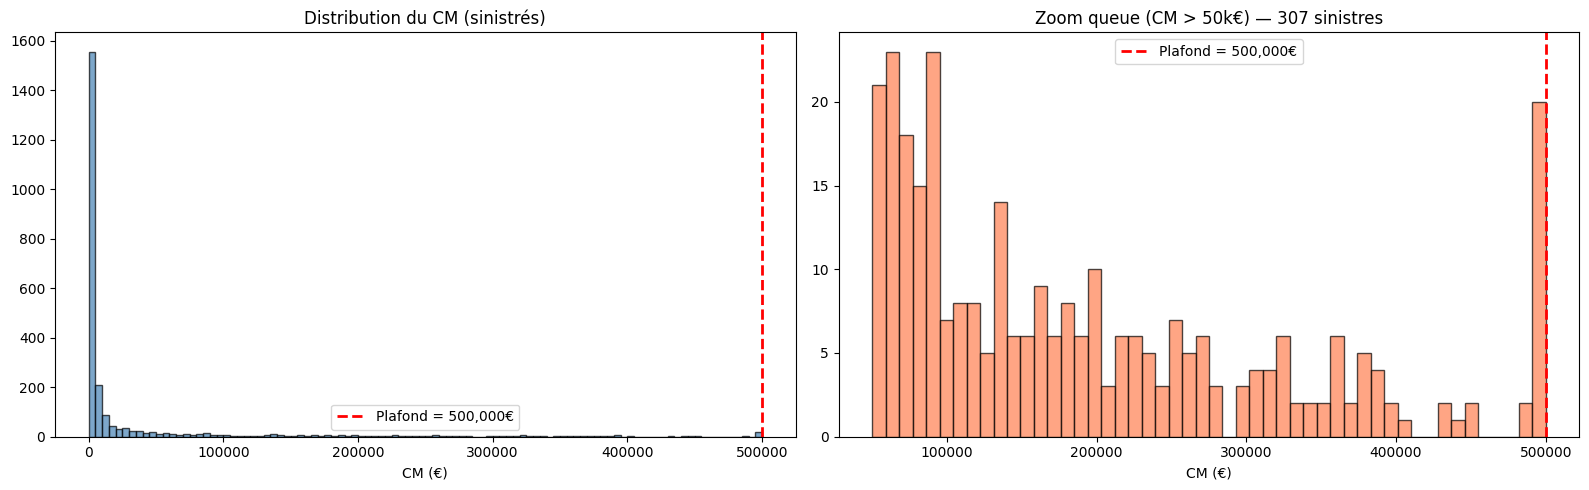

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution des CM > 0 avec marqueur du plafond
cm_pos = sinistres['CM']
axes[0].hist(cm_pos, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=plafond, color='red', linestyle='--', linewidth=2, label=f'Plafond = {plafond:,}€')
axes[0].set_title('Distribution du CM (sinistrés)')
axes[0].set_xlabel('CM (€)')
axes[0].legend()

# Zoom sur la queue (CM > 50 000€)
cm_queue = sinistres[sinistres['CM'] > 50000]['CM']
axes[1].hist(cm_queue, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(x=plafond, color='red', linestyle='--', linewidth=2, label=f'Plafond = {plafond:,}€')
axes[1].set_title(f'Zoom queue (CM > 50k€) — {len(cm_queue)} sinistres')
axes[1].set_xlabel('CM (€)')
axes[1].legend()

plt.tight_layout()
plt.show()

Le zoom sur la queue (graphique de droite) est très parlant :
- La distribution décroît progressivement de 50k à 450k€ — comportement classique d'une queue lourde.
- Puis un **spike brutal à 500k€** (20 sinistres) qui casse la décroissance naturelle. C'est la signature visuelle du plafonnement.
- Sans ce plafond, ces 20 sinistres auraient probablement des CM entre 500k et plusieurs millions — information perdue.

Ce graphique justifie à lui seul la nécessité de traiter les plafonnés séparément dans l'analyse des extrêmes (théorie des valeurs extrêmes, ajustement GPD).

<a id="sec-11-verifications-complementaires"></a>

## 11. Vérifications complémentaires

### 11.1. CM négatifs

L'exploration a révélé des CM négatifs. On les examine avant de les traiter dans le data engineering.

In [47]:
cm_negatifs = train[train['CM'] < 0]

print(f"Nb CM négatifs : {len(cm_negatifs)}")
print(f"\nDétail :")
display(cm_negatifs[['ID', 'ANNEE_ASSURANCE', 'FREQ', 'CM', 'CHARGE']].reset_index(drop=True))

print(f"\nProfil des CM négatifs vs positifs :")
for col in ['KAPITAL32', 'SURFACE1', 'NBBAT1', 'ANCIENNETE', 'NBSINSTRT']:
    if col in train.columns:
        mean_neg = cm_negatifs[col].mean()
        mean_pos = train[train['CM'] > 0][col].mean()
        mean_all = train[col].mean()
        print(f"  {col:15s} : négatifs={mean_neg:>10,.1f}  sinistrés={mean_pos:>10,.1f}  tous={mean_all:>10,.1f}")

Nb CM négatifs : 6

Détail :


,ID,ANNEE_ASSURANCE,FREQ,CM,CHARGE
0,60722,0.7041,1.4202,-5751.0000,-5751.0000
1,77983,0.8384,1.1928,-6.1600,-6.1600
2,108923,0.7514,1.3309,-1918.0000,-1918.0000
3,123862,0.9151,1.0928,-342.6600,-342.6600
4,221268,0.5437,1.8392,-5631.3600,-5631.3600
5,288231,0.8740,1.1442,-216.9500,-216.9500



Profil des CM négatifs vs positifs :
  KAPITAL32       : négatifs= 130,416.7  sinistrés= 141,693.2  tous=  74,441.7
  SURFACE1        : négatifs=   2,108.3  sinistrés=   2,846.7  tous=   1,589.5
  NBBAT1          : négatifs=       6.2  sinistrés=      10.0  tous=       7.0
  ANCIENNETE      : négatifs=       5.5  sinistrés=       5.4  tous=       5.2
  NBSINSTRT       : négatifs=       1.0  sinistrés=       0.5  tous=       0.3


6 sinistres avec CM négatif, tous de faible montant (max -5 751€). Leur profil est cohérent avec des **recours récupérés** ou des **régularisations comptables** :
- Ils ont tous FREQ > 0 (un sinistre a bien eu lieu)
- Leur KAPITAL32 et SURFACE1 sont proches de la moyenne des sinistrés — ce ne sont pas des contrats atypiques
- Leur NBSINSTRT = 1 en moyenne — ils ont un historique de sinistre, ce qui est cohérent avec un recours post-sinistre

Ces 6 observations seront ramenées à CM = 0 dans le data engineering. Ce ne sont pas des sinistres à modéliser — ce sont des flux comptables résiduels.

### 11.2. Cohérence train / test

On vérifie que les distributions des features principales sont similaires entre train et test. Un décalage important signalerait un problème de représentativité.

In [48]:
key_features = ['KAPITAL32', 'SURFACE1', 'NBBAT1', 'ANCIENNETE', 'NBSINSTRT',
                'ANNEE_ASSURANCE', 'KAPITAL12', 'EQUIPEMENT6']
key_features = [c for c in key_features if c in train_input.columns and c in test_input.columns]

print(f"{'Variable':<20} {'Train mean':>12} {'Test mean':>12} {'Train std':>12} {'Test std':>12} {'Ratio mean':>12}")
print("-" * 82)
for col in key_features:
    t_mean = train_input[col].mean()
    te_mean = test_input[col].mean()
    t_std = train_input[col].std()
    te_std = test_input[col].std()
    ratio = te_mean / t_mean if t_mean != 0 else np.nan
    print(f"{col:<20} {t_mean:>12,.2f} {te_mean:>12,.2f} {t_std:>12,.2f} {te_std:>12,.2f} {ratio:>12.3f}")

# Catégorielles : comparer les distributions
cat_check = ['ACTIVIT2', 'VOCATION', 'ESPINSEE']
cat_check = [c for c in cat_check if c in train_input.columns]

for col in cat_check:
    print(f"\n{col} :")
    train_dist = train_input[col].value_counts(normalize=True).sort_index()
    test_dist = test_input[col].value_counts(normalize=True).sort_index()
    comp = pd.DataFrame({'Train': train_dist, 'Test': test_dist}).fillna(0)
    comp['Écart'] = (comp['Test'] - comp['Train']).abs()
    display(comp)

Variable               Train mean    Test mean    Train std     Test std   Ratio mean
----------------------------------------------------------------------------------
KAPITAL32               74,441.68    74,213.79    94,312.94    94,152.89        0.997
SURFACE1                 1,589.53     1,584.79     1,853.74     1,847.75        0.997
NBBAT1                       6.96         6.96         5.16         5.16        0.999
ANCIENNETE                   5.18         5.18         3.82         3.82        1.001
NBSINSTRT                    0.27         0.28         0.55         0.56        1.003
ANNEE_ASSURANCE              0.70         0.70         0.35         0.35        0.999
KAPITAL12              120,546.09   120,572.26   124,946.66   125,275.77        1.000
EQUIPEMENT6                  5.91         5.91         4.29         4.29        1.000

ACTIVIT2 :


,Train,Test,Écart
ACTIVIT2,,,
ACT1,0.7731,0.7735,0.0004
ACT2,0.0374,0.0380,0.0005
ACT3,0.0139,0.0140,0.0001
ACT4,0.0009,0.0009,0.0000
ACT5,0.1400,0.1387,0.0013
ACT6,0.0026,0.0024,0.0003
ACT7,0.0057,0.0060,0.0003
ACT8,0.0147,0.0150,0.0003
ACT9,0.0116,0.0115,0.0001



VOCATION :


,Train,Test,Écart
VOCATION,,,
VOC1,0.0374,0.0380,0.0005
VOC2,0.0051,0.0051,0.0000
VOC3,0.0028,0.0025,0.0003
VOC4,0.0399,0.0407,0.0008
VOC5,0.0002,0.0001,0.0001
VOC6,0.6372,0.6349,0.0023
VOC7,0.1016,0.1016,0.0000
VOC8,0.1758,0.1772,0.0014



ESPINSEE :


,Train,Test,Écart
ESPINSEE,,,
ESP1,0.0006,0.0004,0.0002
ESP2,0.1249,0.1260,0.0011
ESP3,0.8129,0.8129,0.0000
ESP4,0.0616,0.0607,0.0009


Les distributions train/test sont quasi identiques :
- **Numériques** : tous les ratios de moyenne sont entre 0.997 et 1.003. Les écarts-types sont identiques au dixième près. Aucun drift détectable.
- **ACTIVIT2** : écarts < 0.05% sur toutes les modalités. La modalité dominante (ACT1, ~77%) est parfaitement stable.
- **VOCATION** : même constat, écarts < 0.2%. VOC6 (63.7%) est la référence, stable entre train et test.
- **ESPINSEE** : ESP3 domine (81.3%) avec un écart de 0.001% entre train et test.

**Conclusion** : le test est un échantillon aléatoire du même processus générateur que le train. Aucun data drift, aucun biais de sélection. Les modèles entraînés sur le train se généraliseront sans problème au test.

<a id="sec-12-synthese-et-prochaines-etapes"></a>

## 12. Synthèse et prochaines étapes

Ce premier notebook d'exploration a permis de dresser un portrait complet du dataset. Voici les constats principaux et les actions qui en découlent pour le data engineering.


### Structure du dataset
- 383 610 contrats, 374 features, 3 cibles (FREQ, CM, CHARGE)
- 99.25% de contrats sans sinistre → données très déséquilibrées
- 2 894 sinistrés dont 20 plafonnés à 500k€

### Variables cibles
- FREQ = nb_sinistres / exposition (pas un comptage brut)
- CM bimodal en log → deux populations : attritionnels vs graves
- 14% de la charge portée par 20 sinistres plafonnés
- CM négatifs présents (recours/régularisations)

### Valeurs manquantes
- 278/374 variables ont des NA
- Structure par blocs : météo (environ 57%), socio-démo (environ 5%), RISK (environ 7%), HAUTEUR (environ 62%)
- 266/268 variables ont des NA informatifs (liés à la sinistralité)
- → Créer des flags par bloc + flags individuels avant suppression/imputation

### Variables catégorielles (280)
- 225 ordinales déguisées (tranches) → extraire le numéro d'ordre
- 24 binaires N/O → convertir en 0/1
- 27 vraies catégorielles → encodage adapté (one-hot, target encoding)
- 4 constantes → supprimer
- Variables discriminantes : ACTIVIT2, VOCATION, ESPINSEE, TYPBAT1, COEFASS

### Variables numériques (93)
- Très asymétriques (skewness > 5 fréquent), beaucoup de zéros
- Drivers principaux : taille de l'exploitation (KAPITAL × SURFACE × NBBAT)
- TYPERS : seule corrélation négative avec la sinistralité
- NBSINSTRT : signal indépendant (sinistralité passée)

### Corrélations / Redondance
- Doublons parfaits à supprimer : SURFACE1/SURFACE2, NBBAT1/NBBAT4, EQUIPEMENT6/EQUIPEMENT7
- Blocs fortement corrélés (KAPITAL, SURFACE, NBBAT) → agrégation possible
- Corrélations avec les cibles faibles (<6%) mais attendu vu le déséquilibre

### Prochaines étapes
1. Flags NA (blocs + individuels)
2. Suppression variables >50% NA et constantes
3. Encodage (ordinales, binaires, catégorielles)
4. Nettoyage (doublons, quasi-constantes)
5. Feature engineering (ratios, interactions, agrégations)
6. Gestion de la censure (plafond à 500k€, CM négatifs)
7. Estimation du seuil de grave (théorie des valeurs extrêmes)